Full Stack Deep Learning 02  
Last modified : 2026.04   
제작 : 박광석 (모두의연구소)  

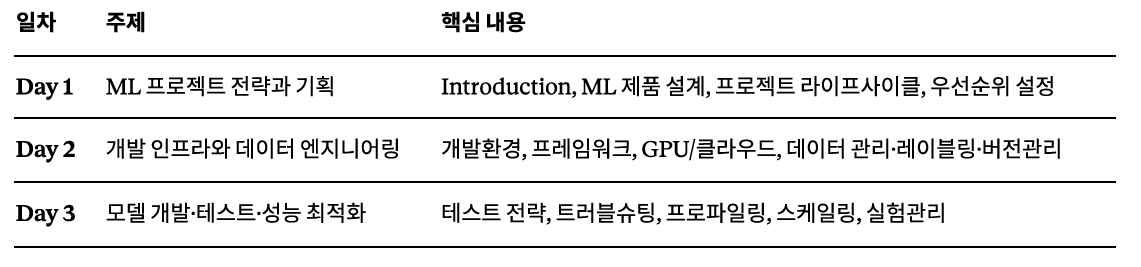

# Day 2. 개발 인프라와 데이터 엔지니어링

> **Day 1**  에서 다루었듯, ML 프로젝트의 성패는 코드가 아니라 기획에서 결정됩니다. 오늘은 어제 수립한 전략을 실행하기 위한 **개발 환경, PyTorch 생태계 심화, GPU/클라우드, 그리고 데이터 관리의 실전 기술**을 다룹니다.
>
> **전제**: 여러분은 이미 PyTorch로 모델을 설계·학습시킨 경험이 있고, Transformer 구조와 LLM Fine-tuning, RAG/Agent까지 실습해 본 인재들입니다. 오늘은 그 경험 위에 **프로덕션 수준의 엔지니어링 관행**을 쌓습니다.

---



## Chapter 7. 현대적 ML 엔지니어를 위한 개발 환경



### 7.1 ML 개발의 꿈과 가혹한 현실

많은 이들이 꿈꾸는 ML 개발 프로세스는 단순합니다 — 프로젝트 명세와 샘플 데이터를 주면 시스템이 알아서 학습하고, 대규모로 배포되어 지속적으로 성능이 개선되는 모습을 상상합니다.

하지만 현실은 훨씬 더 복잡합니다:

1. 데이터를 찾고, 집계하고, 프로세싱하고, 정제하고, 레이블링해야 합니다.
2. 모델 아키텍처를 탐색하고 사전 학습된 가중치를 확인해야 합니다.
3. 모델 코드를 작성·편집·디버깅하며 학습 실험을 반복해야 합니다.
4. 실험 결과를 검토한 뒤 다시 아키텍처를 변경하거나 코드를 수정하는 루프를 돌려야 합니다.
5. 겨우 모델을 배포하고 나면, 예측을 모니터링하고 사용자가 생성한 새로운 데이터를 다시 데이터셋에 추가하는 데이터 플라이휠 루프를 닫아야 합니다.

여러분은 지금까지 이 과정의 일부(모델 설계 → 학습 → 배포)를 주피터 노트북과 단일 GPU 환경에서 수행해왔습니다. 오늘은 이 경험을 **팀 단위로 확장 가능한 프로덕션 수준의 워크플로우**로 끌어올리는 것이 목표입니다. 그 시작점은 견고한 소프트웨어 엔지니어링 기반의 개발 환경입니다.


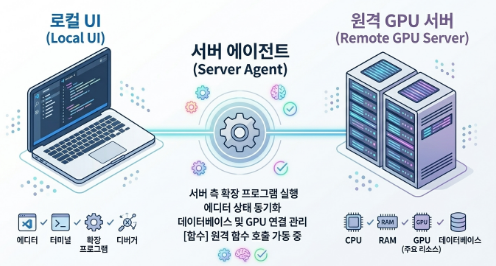



ML 엔지니어를 위한 IDE 선택지는 Vim, PyCharm, 주피터 랩 등 다양하지만, VS Code가 사실상의 표준으로 자리 잡은 데는 명확한 이유가 있습니다.

**원격 개발(Remote Development)**: 여러분이 실습에서 GPU 서버에 SSH로 접속하여 작업한 경험이 있을 것입니다. VS Code Remote는 이 경험을 한 차원 끌어올립니다. 원격 서버에 VS Code Server라는 에이전트를 설치하여, 소스 코드 분석과 디버깅 프로세스는 서버에서 실행되고 UI 렌더링만 로컬로 가져옵니다. 결과적으로 대규모 데이터가 있는 GPU 서버에서 로컬 에디터 수준의 편안함으로 작업할 수 있습니다. ML 엔지니어에게 이 기능은 선택이 아니라 필수입니다.

**내장 Git 버전 관리**: 커밋 확인, 라인 단위 스테이징, diff 비교 등 코드 관리가 에디터 안에서 완결됩니다. 별도의 터미널 창을 오갈 필요가 없어 워크플로우가 간결해집니다.

**린팅(Linting)과 타입 힌트**: 코드를 작성하는 동시에 스타일 규칙을 검사하고 잠재적 오류를 잡아냅니다. Ruff는 Rust로 작성되어 기존 린터(Flake8, Black)보다 10~100배 빠릅니다. MyPy와 같은 정적 타입 체크 도구를 함께 사용하면, 함수 인자의 타입이 맞지 않을 때 코드를 실행하기도 전에 경고를 받을 수 있습니다. 파이썬의 유연함이 강점이기도 하지만, ML 코드에서는 텐서의 형태(shape)나 dtype 불일치 같은 런타임 오류가 빈번하게 발생하므로 타입 힌트를 적극 활용하는 것이 좋습니다.

**AI 코드 어시스턴트 통합**: GitHub Copilot, Cursor 등 AI 기반 코드 생성 도구가 VS Code에서 가장 잘 지원됩니다. 데이터 전처리 보일러플레이트, 설정 파일 작성 등 반복적인 코드 작성 속도를 크게 높여줍니다.



### 7.3 주피터 노트북의 딜레마와 해결책



여러분은 지금까지 주피터 노트북에서 많은 실습을 해왔습니다. 주피터는 데이터 탐색과 프로토타이핑의 '첫 번째 초안(First draft)'으로는 최적입니다. 셀을 실행하면 즉시 결과를 볼 수 있는 빠른 피드백 사이클이 가장 큰 장점입니다.

하지만 프로덕션 수준의 ML 코드를 작성하기에는 구조적 한계가 있습니다:

**문제 1 — 실행 순서의 혼란**: 셀을 위에서 아래로 순서대로 실행하지 않으면 결과가 달라집니다. "나는 잘 되는데 팀원은 안 돼요"라는 상황의 원인이 종종 이것입니다. 셀 3을 실행한 뒤 셀 1을 수정하고 다시 셀 5를 실행하면, 셀 3의 결과가 반영되지 않은 상태가 됩니다.

**문제 2 — 리팩토링의 어려움**: 함수 이름을 변경하거나, 코드를 다른 파일로 옮기는 등의 리팩토링 작업이 번거롭습니다. IDE가 제공하는 "이름 바꾸기(Rename Symbol)" 같은 강력한 기능을 쓸 수 없습니다.

**문제 3 — 버전 관리와 테스트**: 노트북 파일(`.ipynb`)에는 코드뿐 아니라 실행 결과(출력, 이미지)까지 포함되어 있어 파일 크기가 크고, Git diff가 읽기 어렵습니다. 단위 테스트(Unit Test)를 적용하기도 힘듭니다.

**하이브리드 솔루션 — VS Code 내장 노트북 + 모듈화**

해법은 브라우저를 떠나 VS Code 내장 노트북 기능을 사용하는 것입니다. 이렇게 하면 노트북의 즉각적 피드백과 IDE의 강력한 기능을 모두 활용할 수 있습니다.

핵심 전략은 **모듈화**입니다. 탐색과 시각화는 노트북에서 하되, 핵심 로직(모델 정의, 데이터 로딩, 학습 루프)은 별도의 `.py` 모듈로 분리합니다:

```python
# 노트북 상단에 설정 — 모듈 코드 수정 시 노트북 재시작 불필요
%load_ext autoreload
%autoreload 2

# 핵심 로직은 모듈에서 import
from my_project.model import LitClassifier
from my_project.data import create_dataloader

# 노트북에서는 탐색과 시각화에 집중
model = LitClassifier(hidden_dim=256)
train_loader = create_dataloader("data/train.parquet")
```

`autoreload` 매직 명령어가 핵심입니다. 이것을 설정해두면, `my_project/model.py` 파일을 VS Code에서 수정하고 저장할 때마다 노트북을 재시작하지 않아도 변경 사항이 자동으로 반영됩니다. 이렇게 하면 탐색은 노트북에서, 핵심 코드는 `.py` 파일에서 관리하므로 Git 버전 관리와 테스트가 자연스러워집니다.



### 7.4 재현 가능한 파이썬 환경 구축



"어제는 됐는데 오늘은 안 되는" 문제를 경험해 보셨나요? 이 현상의 근본 원인은 대부분 환경 관리입니다. 여러분이 사용해온 PyTorch, transformers, CUDA 등은 다층적인 의존성이 얽혀 있어 특히 까다롭습니다.

**왜 `pip install`만으로는 부족한가?**

단순히 `pip install torch transformers`를 실행하면 그 시점에 가장 최신 버전이 설치됩니다. 일주일 뒤 팀원이 같은 명령어를 실행하면, 그 사이에 라이브러리 버전이 올라가 미묘하게 다른 환경이 만들어집니다. 더 심각한 경우, 새로운 버전의 라이브러리가 기존 코드와 호환되지 않아 학습 결과가 달라지거나 오류가 발생합니다.

**3단계 환경 구축 전략:**

**(1) 뼈대 잡기 — Conda 또는 uv**: 가장 밑단에 있는 Python 버전과 CUDA 버전을 관리합니다. GPU 학습에 필요한 CUDA 라이브러리는 운영체제 수준의 의존성이라 `pip`만으로는 관리가 어렵습니다. Conda는 이런 바이너리 의존성 관리에 강합니다. `uv`는 Rust 기반의 차세대 패키지 매니저로, Conda 대비 10배 이상 빠른 설치 속도를 자랑하며 빠르게 채택되고 있습니다.

**(2) 살 붙이기 — 의존성 잠금(Locking)**: 우리가 직접 사용하는 라이브러리(torch, transformers 등)는 `requirements.in` 파일에 최소한의 제약만 명시하고, `pip-tools`나 `uv lock`이 상호 호환되는 모든 하위 의존성의 정확한 버전을 찾아 `requirements.txt`로 고정합니다. 이 파일을 Git에 커밋하면, 언제 어디서든 동일한 환경을 복제할 수 있습니다.

**(3) 자동화 — Makefile**: 환경 구축에는 `conda env create`, `pip-compile`, `pip-sync` 등 여러 명령어가 필요합니다. 이 복잡한 과정을 `make install` 한 줄로 자동화합니다. 새로운 팀원이 합류했을 때 "이 명령어 하나만 실행하세요"라고 말할 수 있어야 합니다.

핵심 원칙은 **결정적 빌드(Deterministic Build)** — 내 컴퓨터, 팀원 컴퓨터, 클라우드 서버 어디에서도 동일한 환경이 재현되는 것입니다.



### 7.5 코드 품질 관리: 린팅, 포매팅, CI

개발 환경이 갖춰졌다면, 코드 품질을 자동으로 관리하는 습관을 들여야 합니다.

**포매터(Formatter)**: Ruff나 Black은 코드 스타일(들여쓰기, 줄 길이 등)을 자동으로 통일합니다. 팀원 간 "탭 vs 스페이스" 논쟁을 원천 차단합니다. 저장할 때마다 자동 포매팅되도록 VS Code를 설정하세요.

**린터(Linter)**: 정의되지 않은 변수 사용, 미사용 import, 잠재적 타입 오류 등을 코드 실행 전에 잡아냅니다. Ruff는 린팅과 포매팅을 모두 처리하면서도 기존 도구의 100배 속도를 제공합니다.

**Pre-commit Hook**: `git commit`을 실행하기 전에 린팅과 포매팅을 자동으로 수행합니다. CI 서버에서 실패를 발견하기 전에 로컬에서 먼저 문제를 잡을 수 있어 피드백 루프가 짧아집니다.

**GitHub Actions 등 CI 파이프라인**: 모든 푸시/풀 리퀘스트에서 짧은 테스트와 린팅을 자동 실행합니다. 전체 학습 같은 긴 테스트는 별도의 스케줄(예: 매일 밤)에 맡깁니다.



> **✅ Chapter 7 체크포인트**
> 1. VS Code의 원격 개발 기능이 ML 엔지니어에게 왜 필수적인지, GPU 서버 활용 관점에서 설명할 수 있으신가요?
> 2. 주피터 노트북의 세 가지 문제점(실행 순서, 리팩토링, 버전 관리)을 각각 어떻게 해결하는지 "하이브리드 솔루션"의 관점에서 설명해 보세요.
> 3. "결정적 빌드"가 보장되지 않았을 때, 팀 협업에서 어떤 문제가 발생하는지 경험이나 예시를 떠올려 보실 수 있나요?
> 4. `requirements.in`과 `requirements.txt`의 역할 차이를 설명할 수 있으신가요?

---



**✅ Chapter 7 체크포인트**
1. VS Code의 원격 개발 기능이 ML 엔지니어에게 왜 필수적인지, GPU 서버 활용 관점에서 설명할 수 있으신가요?
- ML 모델 학습에는 고성능 GPU가 필수적이지만, 개발자의 개인 랩탑에서 이를 감당하기는 불가능에 가깝습니다. VS Code의 원격 개발(Remote-SSH 등) 기능은 다음과 같은 이유로 필수적입니다.

  - 끊김 없는 개발 경험 (Seamless Experience): 과거에는 로컬에서 코드를 짜고 FTP나 Git으로 GPU 서버에 코드를 올린 뒤, 터미널(SSH)로 접속해 실행하는 번거로운 과정을 거쳤습니다. VS Code 원격 개발을 사용하면 로컬 환경의 에디터를 그대로 사용하면서, 코드 실행과 파일 저장은 GPU 서버에서 직접 이루어집니다.

  - 서버 자원의 즉각적인 활용: 무거운 데이터셋을 로컬에 다운로드할 필요 없이 서버에 있는 테라바이트급 데이터를 즉시 읽어들이고, 코드를 수정하자마자 서버의 GPU를 할당받아 즉각적으로 모델 학습을 테스트할 수 있습니다.

  - 에디터 리소스 분리: 에디터의 UI 랜더링은 로컬 랩탑의 리소스를 사용하고, 무거운 연산(IntelliSense, 린팅, 파이썬 실행)은 서버의 리소스를 사용하므로 쾌적한 개발이 가능합니다.

2. 주피터 노트북의 세 가지 문제점(실행 순서, 리팩토링, 버전 관리)을 각각 어떻게 해결하는지 "하이브리드 솔루션"의 관점에서 설명해 보세요.

- 실행 순서 (비순차적 실행 문제):
  - 문제: 노트북은 셀을 위아래로 자유롭게 실행할 수 있어, 메모리상의 변수 상태(Hidden State)와 눈에 보이는 코드 순서가 달라져 치명적인 버그를 유발합니다.
  - 해결: 데이터 전처리, 모델 아키텍처, 학습 루프 등의 핵심 로직을 .py 파일로 추출합니다. 파이썬 스크립트는 무조건 위에서 아래로 순차 실행되므로 상태 꼬임 문제가 원천 차단됩니다.

- 리팩토링의 어려움:
  - 문제: 여러 셀에 흩어진 변수나 함수 이름을 한 번에 변경하거나, 함수 정의로 바로 이동(Jump to definition)하는 등의 IDE 기능을 활용하기 어렵습니다.
  - 해결: .py 파일로 코드를 모듈화하면 VS Code 등의 강력한 IDE 기능을 온전히 사용할 수 있어 안전하고 빠른 리팩토링이 가능해집니다.

- 버전 관리 (Git Conflict):
  - 문제: .ipynb 파일은 내부적으로 복잡한 JSON 형태로 저장되며, 셀의 실행 횟수(execution count)나 출력된 이미지 메타데이터까지 저장합니다. 이로 인해 코드 한 줄만 바꿔도 Git Diff를 읽을 수 없고 충돌(Conflict) 해결이 지옥이 됩니다.
  - 해결: 비즈니스 로직이 담긴 .py 파일만 Git으로 엄격하게 버전 관리하고, 주피터 노트북은 .py의 함수를 import하여 결과를 확인하는 껍데기(인터페이스) 용도로만 사용합니다.

3. "결정적 빌드"가 보장되지 않았을 때, 팀 협업에서 어떤 문제가 발생하는지 경험이나 예시를 떠올려 보실 수 있나요?
- 결정적 빌드란 "언제, 누가, 어디서 환경을 구축하든 완전히 동일한 패키지 버전과 의존성 트리가 설치되는 것"을 의미합니다. 이것이 보장되지 않으면 이른바 *"제 컴퓨터에서는 잘 되는데요?"*라는 전형적인 문제가 발생합니다.

- 경험적 예시 (API 변경에 따른 런타임 에러):

  - 개발자 A가 pandas 버전을 명시하지 않고 모델 코드를 작성했습니다. 당시 설치된 버전은 1.5.0이었습니다.
  - 두 달 뒤, 신규 입사자 B가 저장소를 클론받아 설치 명령어를 실행했습니다. 이때 pandas 2.0.0이 설치되었습니다.
  - 2.0.0에서 폐기(Deprecated)된 함수를 사용했던 A의 코드는 B의 환경에서만 에러를 뿜으며 동작하지 않습니다. B는 본인이 무엇을 잘못했는지 찾느라 며칠을 허비하게 됩니다.

- ML 특화 예시 (재현성 실패):
  - 라이브러리의 마이너 버전 차이(예: PyTorch나 NumPy)로 인해 난수 생성(Random Seed) 방식이나 부동소수점 연산 처리가 미세하게 달라질 수 있습니다. 코드는 정상 실행되지만, A가 학습했을 때와 B가 재현했을 때 모델의 성능(Accuracy)이 다르게 나오는 디버깅하기 매우 까다로운 상황이 발생합니다.

4. `requirements.in`과 `requirements.txt`의 역할 차이를 설명할 수 있으신가요?

- requirements.in (인간을 위한 파일 - 의존성 선언):
  - 역할: 프로젝트에 직접적으로 필요한 최상위 패키지만 명시합니다.
  - 특징: 개발자의 의도가 담겨 있으며, 유지보수가 쉽습니다. 버전은 크게 제한하지 않거나 호환되는 범위만 적습니다.
  - 예시: pandas, scikit-learn, fastapi

- requirements.txt (기계를 위한 파일 - 결정적 빌드 보장):
  - 역할: 최상위 패키지가 의존하는 하위 패키지(Transitive dependencies)들까지 포함해 모든 패키지의 정확한 버전을 고정(Pinning)합니다.
  - 특징: pip-tools의 pip-compile 같은 명령어를 통해 .in 파일로부터 자동 생성됩니다. 서버에 배포하거나 팀원이 환경을 세팅할 때는 무조건 이 파일을 사용하여 환경의 파편화를 막습니다.
  - 예시: pandas==2.0.3, numpy==1.24.3, pytz==2023.3 ... (수십 개의 패키지가 엄격한 버전과 함께 해시값까지 기록됨)


## Chapter 8. PyTorch 생태계 심화 — 스파게티 코드에서 프로덕션 코드로



### 8.1 여러분의 PyTorch 코드, 프로덕션에 준비되어 있는가?

여러분은 이미 `nn.Module`로 모델을 정의하고, `DataLoader`로 배치를 구성하며, `loss.backward()`와 `optimizer.step()`으로 학습 루프를 작성하는 데 익숙합니다. 다음과 같은 코드를 수없이 작성해 보셨을 것입니다:

```python
# 여러분이 익숙한 "전통적인" PyTorch 학습 루프
for epoch in range(num_epochs):
    for batch in train_loader:
        x, y = batch
        optimizer.zero_grad()
        y_hat = model(x)
        loss = loss_fn(y_hat, y)
        loss.backward()
        optimizer.step()
```

이 코드는 실습에서는 잘 작동합니다. 하지만 프로덕션 환경으로 옮기려면, 다음과 같은 질문들에 답해야 합니다:

- GPU가 4개로 늘어나면 학습 코드를 어떻게 수정해야 하나요?
- 학습 도중 서버가 죽으면 처음부터 다시 시작해야 하나요?
- 100번의 실험에서 어떤 하이퍼파라미터가 어떤 결과를 냈는지 어떻게 추적하나요?
- 16비트 정밀도(Mixed Precision)로 전환하려면 코드를 얼마나 바꿔야 하나요?
- 학습률 스케줄러, 얼리 스토핑, 최고 성능 모델 체크포인팅은 어디에 넣어야 하나요?

이 질문들 하나하나에 답하려면 수십~수백 줄의 "엔지니어링" 코드가 필요합니다. 이 코드를 직접 작성하면 모델마다 같은 실수를 반복하고, 팀원마다 다른 방식으로 구현하게 됩니다. 바로 이 문제를 해결하는 것이 **PyTorch Lightning**입니다.



### 8.2 기존 PyTorch 코드를 Lightning으로 전환하기 — Before & After



먼저 여러분이 익숙한 "전통적인" PyTorch 학습 코드의 전체 구조를 봅시다. 그리고 이것이 Lightning에서 어떻게 바뀌는지 나란히 비교합니다.

**Before — 전통적인 PyTorch (여러분이 써온 방식)**

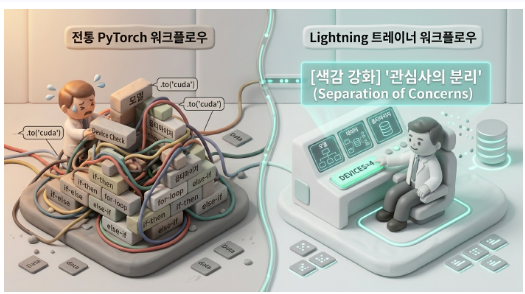

```python
import torch
from torch import nn
from torch.utils.data import DataLoader

# 1. 모델 정의
model = nn.Sequential(nn.Linear(784, 128), nn.ReLU(), nn.Linear(128, 10))
model = model.to("cuda")

# 2. 옵티마이저, 손실 함수
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

# 3. 학습 루프 — 이 안에 모든 것이 섞여 있음
for epoch in range(num_epochs):
    model.train()
    for batch in train_loader:
        x, y = batch
        x, y = x.to("cuda"), y.to("cuda")     # GPU 전송을 매번 직접
        x = x.view(x.size(0), -1)               # shape 변환도 루프 안에
        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

    # 검증 — 학습 루프와 뒤섞임
    model.eval()
    val_loss_sum = 0
    correct = 0
    with torch.no_grad():
        for batch in val_loader:
            x, y = batch
            x, y = x.to("cuda"), y.to("cuda")
            x = x.view(x.size(0), -1)
            logits = model(x)
            val_loss_sum += loss_fn(logits, y).item()
            correct += (logits.argmax(1) == y).sum().item()
    
    print(f"Epoch {epoch}: val_loss={val_loss_sum/len(val_loader):.4f}")
```

이 코드의 문제점을 짚어봅시다:
- `.to("cuda")`를 매번 직접 호출해야 합니다. CPU로 바꾸려면 모든 곳을 수정해야 합니다.
- 학습 루프와 검증 루프가 한 파일에 뒤섞여 있습니다.
- 메트릭 집계(loss 합산, accuracy 계산)를 직접 해야 합니다.
- 체크포인팅, 얼리 스토핑, 로깅을 추가하려면 루프 안에 코드가 계속 늘어납니다.
- GPU가 4개로 늘어나면? 코드를 근본적으로 재작성해야 합니다.



**After — PyTorch Lightning**

```python
import torch
from torch import nn
import pytorch_lightning as pl

class LitClassifier(pl.LightningModule):
    def __init__(self, hidden_dim=128, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()  # ← [NEW] 하이퍼파라미터 자동 저장·로깅

        self.model = nn.Sequential(
            nn.Linear(28 * 28, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 10)
        )
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x.view(x.size(0), -1))

    def training_step(self, batch, batch_idx):
        x, y = batch                          # ← .to("cuda") 불필요! Trainer가 처리
        logits = self(x)
        loss = self.loss_fn(logits, y)
        self.log("train_loss", loss)           # ← [NEW] 자동 로깅
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("val_loss", loss, prog_bar=True)   # ← 프로그레스 바에 표시
        self.log("val_acc", acc, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)
```

**무엇이 달라졌는지 정리합니다:**




| 항목         | 전통 PyTorch          | Lightning                                       |
| ---------- | ------------------- | ----------------------------------------------- |
| GPU 전송     | `.to("cuda")` 매번 호출 | `Trainer`가 자동 처리                                |
| 학습/검증 분리   | 하나의 루프에 뒤섞임         | `training_step()` / `validation_step()`으로 명확 분리 |
| 메트릭 로깅     | `print()` 또는 수동 집계  | `self.log()` 한 줄 → TensorBoard, W&B 자동 연동       |
| 하이퍼파라미터 관리 | 변수로 흩어져 있음          | `save_hyperparameters()`로 자동 저장 및 복원            |
| GPU 4대 확장  | 코드 재작성 필요           | `Trainer(devices=4)` 파라미터 한 줄                   |
| 체크포인팅      | 직접 구현               | `ModelCheckpoint` 콜백 연결                         |



핵심을 한 문장으로 요약하면: **여러분이 관심 있는 부분(모델, 손실함수, 최적화)은 `LightningModule`에, 관심 없는 부분(GPU 관리, 분산, 로깅)은 `Trainer`에 위임합니다.**



### 8.3 LightningModule 심화 — 실전에서 필요한 메서드들

위의 기본 구조에 실전에서 자주 추가하는 기능들을 하나씩 살펴봅시다.

**학습률 스케줄러 추가하기**

실습에서 고정 학습률을 사용해 보셨을 텐데, 실전에서는 학습률을 동적으로 조절하는 스케줄러가 거의 필수입니다. `configure_optimizers`에서 옵티마이저와 스케줄러를 함께 반환하면 됩니다:

```python
def configure_optimizers(self):
    optimizer = torch.optim.AdamW(self.parameters(), lr=self.hparams.lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=self.trainer.max_epochs
    )
    return {
        "optimizer": optimizer,
        "lr_scheduler": {
            "scheduler": scheduler,
            "interval": "epoch",   # 매 에포크마다 학습률 갱신
        }
    }
```

Warmup + Cosine Decay처럼 복잡한 스케줄도 같은 방식으로 적용할 수 있습니다. `self.trainer.max_epochs`처럼 Trainer의 설정값에 접근할 수 있다는 점이 편리합니다.

**에포크 단위 메트릭 집계**

`self.log()`는 기본적으로 스텝 단위로 기록합니다. 에포크 전체의 평균 정확도를 구하려면 `on_epoch=True`를 추가하세요:

```python
def validation_step(self, batch, batch_idx):
    x, y = batch
    logits = self(x)
    loss = self.loss_fn(logits, y)
    acc = (logits.argmax(dim=1) == y).float().mean()
    
    # on_epoch=True → 에포크가 끝날 때 자동으로 평균을 계산
    self.log("val_loss", loss, on_epoch=True, prog_bar=True)
    self.log("val_acc", acc, on_epoch=True, prog_bar=True)
```

이것이 전통 PyTorch에서 `val_loss_sum += ...`로 직접 합산하던 것을 대체합니다.

**테스트 단계**

학습과 검증이 끝나고, 최종 모델의 성능을 따로 테스트할 때:

```python
def test_step(self, batch, batch_idx):
    x, y = batch
    logits = self(x)
    loss = self.loss_fn(logits, y)
    acc = (logits.argmax(dim=1) == y).float().mean()
    self.log("test_loss", loss)
    self.log("test_acc", acc)

# 사용법: 학습이 끝난 뒤
trainer.test(model, dataloaders=test_loader)
```

**예측(추론) 단계**

배포 시 레이블 없이 입력만 주고 예측 결과를 얻을 때:

```python
def predict_step(self, batch, batch_idx):
    x = batch[0]  # 레이블 없이 입력만
    return self(x)

# 사용법
predictions = trainer.predict(model, dataloaders=predict_loader)
```

### 8.4 LightningDataModule — 데이터 로딩도 구조화하기

모델 코드를 `LightningModule`로 구조화했다면, 데이터 로딩 코드도 구조화하는 것이 자연스럽습니다. `LightningDataModule`은 데이터 준비·분할·로딩을 하나의 재사용 가능한 클래스로 묶어줍니다.

```python
class MNISTDataModule(pl.LightningDataModule):
    def __init__(self, data_dir="./data", batch_size=64, num_workers=4):
        super().__init__()
        self.save_hyperparameters()

    def setup(self, stage=None):
        """데이터 다운로드 및 train/val/test 분할. 모든 GPU에서 호출됨."""
        from torchvision import datasets, transforms
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])
        
        if stage == "fit" or stage is None:
            full_dataset = datasets.MNIST(self.hparams.data_dir, train=True,
                                          download=True, transform=transform)
            self.train_dataset, self.val_dataset = torch.utils.data.random_split(
                full_dataset, [55000, 5000]
            )
        
        if stage == "test" or stage is None:
            self.test_dataset = datasets.MNIST(self.hparams.data_dir, train=False,
                                               download=True, transform=transform)

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.hparams.batch_size,
                          shuffle=True, num_workers=self.hparams.num_workers,
                          persistent_workers=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.hparams.batch_size,
                          num_workers=self.hparams.num_workers,
                          persistent_workers=True)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.hparams.batch_size,
                          num_workers=self.hparams.num_workers)
```

**왜 DataModule을 쓰는가?**

전통 PyTorch에서는 데이터 로딩 코드가 학습 스크립트 곳곳에 흩어져 있었습니다. DataModule을 쓰면:
- 같은 데이터셋을 다른 모델에서 재사용하기 쉽습니다.
- `num_workers`, `batch_size` 같은 설정이 한 곳에서 관리됩니다.
- 분산 학습 시 각 GPU에서 데이터 분할이 자동으로 처리됩니다.
- `persistent_workers=True`를 설정하면 에포크 사이에 워커 프로세스가 유지되어 데이터 로딩 오버헤드가 줄어듭니다.

**사용법:**

```python
model = LitClassifier(hidden_dim=256, lr=1e-3)
data = MNISTDataModule(batch_size=128, num_workers=4)

trainer = pl.Trainer(max_epochs=10, accelerator="auto")
trainer.fit(model, datamodule=data)       # 학습 + 검증
trainer.test(model, datamodule=data)      # 테스트
```

### 8.5 Trainer 심화 — 파라미터 한 줄로 바꾸는 엔지니어링 설정



`Trainer` 객체가 여러분이 직접 작성해야 했던 수백 줄의 엔지니어링 코드를 대체합니다.   
자주 사용하는 설정들을 상황별로 정리합니다:

```python
# ── 기본 학습 ──
trainer = pl.Trainer(max_epochs=10, accelerator="auto", devices=1)

# ── GPU 4대 분산 학습 (모델 코드 변경 없음!) ──
trainer = pl.Trainer(accelerator="gpu", devices=4, strategy="ddp")

# ── 16비트 혼합 정밀도 (메모리 절반, 속도 ~2배) ──
trainer = pl.Trainer(precision="16-mixed")

# ── 그래디언트 축적 (작은 GPU에서 큰 배치 효과) ──
# 4번의 forward/backward를 모아서 1번 업데이트 → 실효 배치 = batch_size × 4
trainer = pl.Trainer(accumulate_grad_batches=4)

# ── 그래디언트 클리핑 (그래디언트 폭주 방지) ──
trainer = pl.Trainer(gradient_clip_val=1.0)

# ── 암기 테스트 (학습 파이프라인 스모크 테스트) ──
trainer = pl.Trainer(overfit_batches=1, max_epochs=50)

# ── 프로파일링 (어디가 느린지 진단) ──
trainer = pl.Trainer(profiler="simple")  # 또는 "advanced"로 함수 수준 분석

# ── 빠른 디버그 런 (전체 데이터의 1%만 사용) ──
trainer = pl.Trainer(limit_train_batches=0.01, limit_val_batches=0.01, max_epochs=1)
```

**이것들은 모두 조합 가능합니다.** 실전에서는 보통 다음과 같이 한꺼번에 설정합니다:

```python
trainer = pl.Trainer(
    accelerator="gpu",
    devices=4,
    strategy="ddp",
    precision="16-mixed",
    max_epochs=20,
    gradient_clip_val=1.0,
    accumulate_grad_batches=2,
    callbacks=[
        pl.callbacks.ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=3),
        pl.callbacks.EarlyStopping(monitor="val_loss", patience=5, mode="min"),
        pl.callbacks.LearningRateMonitor(logging_interval="step"),
    ],
    logger=pl.loggers.WandbLogger(project="my-project"),
)
trainer.fit(model, datamodule=data)
```

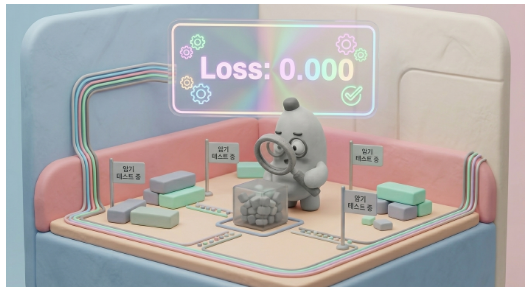

특히 `overfit_batches=1`은 Day 3에서 다룰 트러블슈팅의 핵심 도구입니다. 모델이 단 1개의 배치도 완벽하게 암기하지 못한다면(즉, Loss가 0에 수렴하지 않는다면), 이는 다음과 같은 심각한 버그가 있다는 신호입니다:
- 그래디언트 계산이 깨져서 가중치가 업데이트되지 않는 경우
- 레이블과 데이터의 순서가 뒤섞인 경우 (데이터 셔플링 오류)
- 수치적 불안정성으로 NaN이 발생하는 경우



### 8.6 콜백(Callback) 시스템 — 학습 루프를 건드리지 않고 기능 추가하기

Lightning의 콜백은 학습 루프의 특정 시점에 코드를 주입(Hook)할 수 있는 메커니즘입니다. 모델 코드(`LightningModule`)를 수정하지 않고도 다양한 기능을 추가할 수 있습니다.

**내장 콜백 — 바로 쓸 수 있는 것들:**

```python
# 1. 모델 체크포인팅: 검증 손실이 가장 낮은 시점의 가중치 자동 저장
checkpoint_cb = pl.callbacks.ModelCheckpoint(
    monitor="val_loss",      # 어떤 메트릭을 기준으로 저장할지
    mode="min",              # 이 메트릭이 낮을수록 좋은지(min) 높을수록 좋은지(max)
    save_top_k=3,            # 상위 3개 체크포인트만 보관 (디스크 절약)
    filename="{epoch}-{val_loss:.2f}",  # 파일명에 에포크와 손실값 포함
    save_last=True,          # 마지막 에포크도 항상 저장 (학습 재개용)
)

# 2. 얼리 스토핑: 성능이 더 이상 개선되지 않으면 조기 종료
early_stop_cb = pl.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,              # 5에포크 동안 val_loss가 개선되지 않으면 중단
    mode="min",
    min_delta=0.001,         # 이 값 이상 개선되어야 "개선"으로 인정
)

# 3. 학습률 모니터: 학습률 변화를 자동 로깅 (스케줄러 적용 시 필수)
lr_monitor = pl.callbacks.LearningRateMonitor(logging_interval="step")
```

**커스텀 콜백 — 자신만의 로직 추가:**

예를 들어, 매 에포크 끝에 예측 결과 샘플을 시각화하고 싶다면:

```python
class VisualizePredictions(pl.Callback):
    def on_validation_epoch_end(self, trainer, pl_module):
        """검증 에포크가 끝날 때마다 호출됩니다."""
        # 검증 데이터에서 샘플을 가져와 예측 결과를 시각화하는 로직
        val_batch = next(iter(trainer.datamodule.val_dataloader()))
        x, y = val_batch
        x = x.to(pl_module.device)
        with torch.no_grad():
            logits = pl_module(x[:8])  # 8개 샘플만
            preds = logits.argmax(dim=1)
        
        # W&B나 TensorBoard에 이미지로 기록 가능
        print(f"[Epoch {trainer.current_epoch}] 예측: {preds.tolist()}, 정답: {y[:8].tolist()}")
```

사용법: `trainer = pl.Trainer(callbacks=[checkpoint_cb, early_stop_cb, lr_monitor, VisualizePredictions()])`

콜백 시스템의 핵심 가치는 **관심사의 분리(Separation of Concerns)**입니다. 모델 로직은 `LightningModule`에, 로깅·체크포인팅·시각화 등의 부가 기능은 콜백에 분리하면, 각각을 독립적으로 수정·재사용할 수 있습니다.



### 8.7 체크포인팅 심화 — 실험을 잃지 않는 방법

클라우드에서 GPU를 빌려 학습하다가 스팟 인스턴스가 갑자기 회수되면 어떻게 될까요?  
체크포인팅이 없다면 모든 진행 상황을 잃게 됩니다.

```python
# 검증 손실이 가장 낮은 모델을 자동 저장
checkpoint_cb = pl.callbacks.ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=3,        # 상위 3개 체크포인트 보관
    filename="{epoch}-{val_loss:.2f}"
)

# 성능이 더 이상 개선되지 않으면 조기 종료
early_stop_cb = pl.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,           # 5에포크 동안 개선 없으면 중단
    mode="min"
)

trainer = pl.Trainer(callbacks=[checkpoint_cb, early_stop_cb])
```

Lightning의 체크포인팅은 모델 가중치뿐 아니라 옵티마이저 상태, 에포크 번호, 스케줄러 상태까지 모두 저장합니다. 서버가 죽어도 마지막 체크포인트에서 이어서 학습할 수 있습니다.



### 8.8 혼합 정밀도(Mixed Precision) — 공짜 점심에 가장 가까운 것

여러분이 실습에서 `float32`로 학습했다면, `precision="16-mixed"` 한 줄로 메모리를 절반으로 줄이고 속도를 ~2배 높일 수 있습니다. "공짜 점심은 없다"는 격언의 거의 유일한 예외입니다.  

작동 원리: 순전파(Forward)와 역전파(Backward)는 16비트로 빠르게 계산하되, 가중치 업데이트는 32비트 마스터 가중치에서 수행하여 수치적 안정성을 유지합니다. 최신 GPU(Ampere 이상)는 BF16을 지원하여 FP16보다 수치적 안정성이 더 높습니다.  

주의: 극히 드물게 수치적 불안정성이 발생할 수 있으므로, 혼합 정밀도 적용 전후로 검증 성능을 반드시 비교하세요.  


### 8.9 분산 학습 — 모델이 GPU 하나에 안 들어갈 때


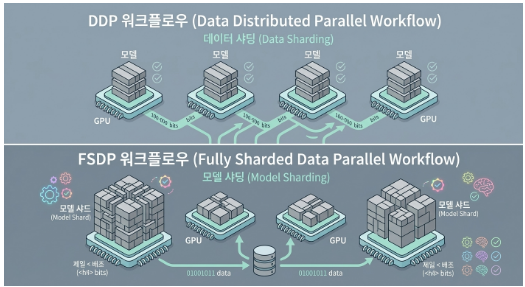



여러분이 Fine-tuning했던 LLM을 떠올려 보세요. 수십억 개의 파라미터를 가진 모델은 단일 GPU 메모리에 담기지 않습니다. 이때 사용하는 전략들을 "언제 무엇을 쓰는가"의 관점에서 정리합니다.

**상황 1: 모델은 GPU 하나에 들어가지만, 학습을 빠르게 하고 싶을 때**
→ **DDP (Distributed Data Parallel)**: 데이터를 여러 GPU에 나누어 병렬 학습합니다. 각 GPU가 동일한 모델 복사본을 가지고 다른 데이터 배치를 처리한 뒤, 그래디언트를 평균화합니다. 가장 먼저 시도해야 할 전략입니다.

**상황 2: 모델 자체가 GPU 하나에 안 들어갈 때**
→ **FSDP (Fully Sharded Data Parallel)**: 모델 파라미터, 그래디언트, 옵티마이저 상태까지 모든 것을 여러 GPU에 쪼개어(Sharding) 저장합니다. 필요한 시점에만 해당 파라미터를 모아서(All-gather) 연산하고 다시 흩뿌립니다.

```python
# DDP — 데이터를 나눠서 빠르게
trainer = pl.Trainer(accelerator="gpu", devices=4, strategy="ddp")

# FSDP — 모델을 쪼개서 거대 모델도 학습 가능
trainer = pl.Trainer(accelerator="gpu", devices=8, strategy="fsdp")
````

**Adam 옵티마이저의 숨겨진 메모리 비용**: 여러분이 자주 쓰는 Adam은 파라미터마다 Momentum과 Variance라는 두 가지 상태값을 저장합니다. 모델 파라미터가 P개라면, 옵티마이저 상태에 2P개, 혼합 정밀도 학습 시 FP32 마스터 가중치에 1P개가 추가로 필요합니다. 결과적으로 **옵티마이저만으로 파라미터 크기의 3~4배 메모리**가 필요합니다. 이것이 FSDP가 옵티마이저 상태 샤딩부터 시작하는 이유입니다.

**GPU 간 통신 — 인터커넥트의 중요성**: 분산 학습에서 GPU들은 그래디언트를 서로 교환해야 합니다. 이때 GPU 간 통신 속도가 전체 학습 속도를 결정합니다. NVLink가 있으면 GPU끼리 직접 초고속 통신이 가능하여 GPU 수에 비례하는 성능 향상을 기대할 수 있습니다. 소비자용 GPU(RTX 시리즈)는 NVLink이 없어 PCIe 버스를 거쳐야 하므로, GPU를 4개 써도 성능은 3배 정도에 그치는 경우가 많습니다.



### 8.10 Hugging Face 생태계 — "바퀴를 새로 발명하지 마세요"

여러분은 이미 `transformers` 라이브러리를 통해 사전 학습된 모델을 활용해본 경험이 있습니다. 이 경험을 확장하면:

**Hugging Face Hub**: 100만 개 이상의 사전 학습된 모델과 수만 개의 데이터셋을 보유한 ML의 GitHub입니다. NLP, 비전, 오디오, 멀티모달 등 모든 태스크를 지원합니다.

**전이 학습(Transfer Learning)의 핵심**: Hub에서 모델을 가져오는 근본적인 이유는, 거대 데이터셋으로 학습된 모델이 이미 데이터의 일반적인 특징(문법, 에지, 텍스처 등)을 추출하는 법을 알고 있기 때문입니다. 이를 새로운 태스크에 적용하면, 적은 데이터로도 훨씬 빠르게 수렴하고 높은 성능을 얻을 수 있습니다.

**실무 전략 — Fine-tuning의 단계적 접근**:
1. 먼저 사전 학습된 모델의 하위 레이어를 고정(Freeze)하고, 최상위 분류 레이어(Head)만 학습시킵니다.
2. 성능이 정체되면, 하위 레이어를 점진적으로 해동(Unfreeze)하며 전체 모델을 낮은 학습률로 Fine-tuning합니다.
3. 이 패턴은 여러분이 LLM Fine-tuning에서 경험한 것과 정확히 같습니다.

**모델 보안 주의**: 외부에서 가중치 파일을 다운로드할 때 보안 위험이 있습니다. 특히 `pickle` 기반 포맷은 파일 로드 시 임의의 코드를 실행할 수 있습니다. `safetensors` 포맷을 사용하면 이런 위험 없이 안전하게 모델을 로드할 수 있으므로, Hugging Face에서 모델을 다운로드할 때는 `safetensors` 포맷을 우선 선택하세요.



### 8.11 torch.compile — PyTorch 2.x의 핵심 변화

여러분이 사용해온 PyTorch는 코드가 실행되는 시점에 계산 그래프가 생성되는 '동적 그래프(Define-by-run)' 방식입니다. 이 덕분에 파이썬 디버거를 그대로 쓸 수 있고, 조건문이나 반복문도 자유롭게 사용할 수 있습니다. 하지만 한편으로는, 프레임워크가 전체 연산 흐름을 미리 볼 수 없어 최적화 기회를 놓치는 단점이 있었습니다.

`torch.compile`은 이 문제를 해결합니다. 동적 그래프의 유연함은 유지하면서, 실행 시점에 그래프를 분석하여 자동으로 최적화합니다.

```python
# 기존 모델에 한 줄만 추가
model = torch.compile(model)
```

내부적으로 수행하는 최적화:
- **커널 퓨전(Kernel Fusion)**: 여러 개의 작은 연산(예: ReLU → Dropout → LayerNorm)을 하나의 GPU 커널로 합칩니다. GPU 커널 하나를 실행할 때마다 오버헤드가 있는데, 이를 줄여줍니다.
- **불필요한 메모리 할당 제거**: 중간 결과를 저장하기 위한 임시 텐서 생성을 최소화합니다.
- 결과적으로 **추론 속도 20~50% 개선**이 가능하며, 학습 시에도 적용할 수 있습니다.

주의: 모든 PyTorch 코드가 `torch.compile`과 호환되는 것은 아닙니다. 복잡한 제어 흐름이나 동적 shape를 사용하는 코드에서는 호환 문제가 발생할 수 있습니다. 먼저 `compile` 없이 코드가 정상 동작하는 것을 확인한 뒤, 속도가 필요한 시점에 적용하세요.

### 8.12 프로파일러 — "어디가 느린지" 직접 확인하기

"이 부분이 느릴 것 같다"는 직감으로 최적화하면 대부분 틀립니다. 실제로 측정(프로파일링)해야 합니다. Lightning의 내장 프로파일러는 이를 매우 쉽게 만들어줍니다.

```python
# simple: 각 단계별 요약 통계
trainer = pl.Trainer(profiler="simple", max_epochs=1)

# advanced: 함수 수준의 상세 분석
trainer = pl.Trainer(profiler="advanced", max_epochs=1)
```

프로파일링 결과는 학습 종료 후 콘솔에 출력됩니다. 대략 다음과 같은 형태입니다:



```
Action                  | Mean (s)  | Total (s) | Percentage
---------------------------------------------------------------
run_training_epoch      | 12.5      | 12.5      | 100%
  training_step         | 0.08      | 8.0       | 64%
  get_train_batch       | 0.04      | 4.0       | 32%
  optimizer_step        | 0.005     | 0.5       | 4%
```



이 결과에서 `get_train_batch`(데이터 로딩)가 전체 시간의 32%를 차지한다면, 모델 아키텍처를 아무리 최적화해도 속도 향상은 제한적입니다. 이때는 `DataLoader`의 `num_workers`를 늘리거나, 데이터 포맷을 변경하는 것이 우선입니다.



**직감에 반하는 딥러닝 성능의 특성:**
- Transformer에서 Attention이 아니라 MLP가 더 느린 경우가 있습니다.
- GPU 메모리 부족(OOM)의 원인이 모델이 아니라 옵티마이저 상태인 경우가 많습니다 (Adam은 파라미터의 3~4배 메모리를 씀).
- 모델 연산보다 데이터 로딩이 병목인 경우가 매우 흔합니다.

프로파일링 없이 추측만으로 최적화하지 마세요. Day 3에서 이 주제를 더 깊이 다룹니다.



### 8.13 처음부터 끝까지 — 실전 프로젝트 조립 예제

지금까지 배운 모든 것을 하나로 조립한 실전 수준의 완전한 학습 스크립트입니다. 여러분의 프로젝트에서 이 구조를 템플릿으로 활용하세요.

```python
import torch
from torch import nn
import pytorch_lightning as pl
from torch.utils.data import DataLoader, TensorDataset

# ══════════════════════════════════════════
# 1. LightningModule — "무엇을" 학습시킬 것인가
# ══════════════════════════════════════════
class LitClassifier(pl.LightningModule):
    def __init__(self, input_dim=784, hidden_dim=256, num_classes=10, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes),
        )
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x.view(x.size(0), -1))

    def _shared_step(self, batch):
        """학습/검증/테스트에서 공통으로 사용하는 로직"""
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        return loss, acc

    def training_step(self, batch, batch_idx):
        loss, acc = self._shared_step(batch)
        self.log("train_loss", loss, on_step=True, on_epoch=True)
        self.log("train_acc", acc, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, acc = self._shared_step(batch)
        self.log("val_loss", loss, on_epoch=True, prog_bar=True)
        self.log("val_acc", acc, on_epoch=True, prog_bar=True)

    def test_step(self, batch, batch_idx):
        loss, acc = self._shared_step(batch)
        self.log("test_loss", loss)
        self.log("test_acc", acc)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.hparams.lr)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=self.trainer.max_epochs
        )
        return {"optimizer": optimizer, "lr_scheduler": {"scheduler": scheduler}}


# ══════════════════════════════════════════
# 2. LightningDataModule — 데이터 준비·분할·로딩
# ══════════════════════════════════════════
class MyDataModule(pl.LightningDataModule):
    def __init__(self, batch_size=128, num_workers=4):
        super().__init__()
        self.save_hyperparameters()

    def setup(self, stage=None):
        # 여기에 실제 데이터 로딩 로직을 넣습니다
        # 예시: 가상의 데이터
        x = torch.randn(10000, 1, 28, 28)
        y = torch.randint(0, 10, (10000,))
        full = TensorDataset(x, y)
        self.train_ds, self.val_ds, self.test_ds = \
            torch.utils.data.random_split(full, [8000, 1000, 1000])

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.hparams.batch_size,
                          shuffle=True, num_workers=self.hparams.num_workers,
                          persistent_workers=True, pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.hparams.batch_size,
                          num_workers=self.hparams.num_workers,
                          persistent_workers=True, pin_memory=True)

    def test_dataloader(self):
        return DataLoader(self.test_ds, batch_size=self.hparams.batch_size,
                          num_workers=self.hparams.num_workers)


# ══════════════════════════════════════════
# 3. Trainer — "어떻게" 학습시킬 것인가
# ══════════════════════════════════════════
if __name__ == "__main__":
    model = LitClassifier(hidden_dim=256, lr=1e-3)
    data = MyDataModule(batch_size=128, num_workers=4)

    trainer = pl.Trainer(
        accelerator="auto",
        devices="auto",
        precision="16-mixed",
        max_epochs=20,
        gradient_clip_val=1.0,
        callbacks=[
            pl.callbacks.ModelCheckpoint(
                monitor="val_loss", mode="min", save_top_k=3, save_last=True
            ),
            pl.callbacks.EarlyStopping(
                monitor="val_loss", patience=5, mode="min"
            ),
            pl.callbacks.LearningRateMonitor(logging_interval="step"),
        ],
        logger=pl.loggers.WandbLogger(project="fsdl-day2-practice"),
    )

    # 학습 + 검증
    trainer.fit(model, datamodule=data)

    # 최고 성능 모델로 테스트
    trainer.test(model, datamodule=data, ckpt_path="best")
```

**이 코드의 핵심 패턴들을 정리합니다:**

- **`_shared_step` 패턴**: 학습/검증/테스트에서 공통되는 로직을 private 메서드로 분리합니다. 코드 중복을 제거하고, 세 단계의 로직이 항상 동기화됩니다.
- **`pin_memory=True`**: CPU → GPU 데이터 전송 속도를 높여줍니다. CUDA가 있는 환경에서는 항상 켜두세요.
- **`persistent_workers=True`**: 에포크 사이에 DataLoader 워커 프로세스를 유지합니다. 워커 초기화 오버헤드가 큰 경우 눈에 띄는 속도 향상을 줍니다.
- **`ckpt_path="best"`**: 학습이 끝난 뒤 테스트할 때, 마지막 에포크가 아닌 **검증 성능이 가장 좋았던** 체크포인트를 자동으로 불러옵니다.
- **`if __name__ == "__main__":`**: DDP 분산 학습 시 각 GPU 프로세스가 스크립트를 독립적으로 실행하므로, 이 가드가 없으면 무한 재귀가 발생할 수 있습니다.



> **✅ Chapter 8 체크포인트**
> 1. 전통적인 PyTorch 학습 루프 대비 Lightning으로 전환했을 때 사라지는 코드(직접 안 써도 되는 것) 5가지를 나열할 수 있으신가요?
> 2. `LightningDataModule`의 `setup` 메서드와 `train_dataloader` 메서드의 역할 차이를 설명할 수 있으신가요? 왜 데이터 분할과 DataLoader 생성을 분리하는 것이 중요한가요?
> 3. 이 장에서 배운 `_shared_step` 패턴을 자신의 프로젝트에 적용한다면, 공통 로직과 각 단계(학습/검증/테스트)에서 달라지는 부분은 각각 무엇인가요?
> 4. `overfit_batches=1` 테스트가 실패했을 때 의심해야 할 원인 3가지와, 각각의 디버깅 방법을 설명할 수 있으신가요?
> 5. 8.13의 전체 코드를 여러분의 실제 프로젝트에 맞게 수정한다면, `LitClassifier.__init__`과 `MyDataModule.setup`에서 각각 무엇을 바꿔야 하는지 구체적으로 떠올려 보세요.

---



**✅ Chapter 8 체크포인트**
1. 전통적인 PyTorch 학습 루프 대비 Lightning으로 전환했을 때 사라지는 코드(직접 안 써도 되는 것) 5가지를 나열할 수 있으신가요?
    - 디바이스 할당 (.to(device) / .cuda()): 데이터를 GPU/TPU로 올리는 코드를 프레임워크가 알아서 처리합니다.

    - 학습/평가 모드 전환 (model.train(), model.eval()): 각 에폭과 루프 단계에 맞춰 자동으로 전환됩니다.

    - 기울기 초기화 (optimizer.zero_grad()): 매 배치마다 기울기를 누적하지 않도록 초기화하는 과정이 생략됩니다.

    - 역전파 및 가중치 업데이트 (loss.backward(), optimizer.step()): 손실값을 반환(return loss)하기만 하면, 프레임워크가 최적화 단계를 자동으로 수행합니다.

    - 기울기 계산 비활성화 (with torch.no_grad():): 검증(Validation) 및 테스트(Test) 루프에서 메모리를 아끼기 위해 명시하던 컨텍스트 매니저가 더 이상 필요하지 않습니다.
    (보너스: for epoch in range(epochs): 와 같은 명시적인 훈련 루프 자체도 사라집니다.)


2. `LightningDataModule`의 `setup` 메서드와 `train_dataloader` 메서드의 역할 차이를 설명할 수 있으신가요? 왜 데이터 분할과 DataLoader 생성을 분리하는 것이 중요한가요?
    - setup(self, stage=None) (상태 정의): * 역할: 전체 데이터를 로드하고, Train / Val / Test 셋으로 분할(Split)하며, 필요한 전처리(Scaling 등)를 수행하여 클래스 내부 변수(예: self.train_dataset)에 할당합니다.

    - train_dataloader(self) (로딩 실행): * 역할: setup에서 만들어진 데이터셋을 PyTorch DataLoader로 감싸서 반환합니다. 여기서 배치 사이즈, 워커(Worker) 수 등을 결정합니다.

    - 분리하는 이유: 여러 대의 GPU를 사용하는 분산 학습(DDP) 환경을 구성할 때, 데이터 다운로드나 분할 로직이 GPU마다 중복 실행되거나 충돌하는 것을 막기 위해서입니다. setup은 각 디바이스에 맞게 데이터를 분리하는 논리적 구분을 담당하고, *_dataloader는 그 데이터를 하드웨어로 어떻게 퍼 나를지 물리적 전달을 담당합니다.

3. 이 장에서 배운 `_shared_step` 패턴을 자신의 프로젝트에 적용한다면, 공통 로직과 각 단계(학습/검증/테스트)에서 달라지는 부분은 각각 무엇인가요?
    - 공통 로직 (_shared_step): * 고객의 이전 구매 이력(Input)을 모델에 통과시켜 예측값(Logits)을 얻습니다.

    - 실제 구매한 상품(Target)과 비교하여 손실값(CrossEntropy Loss)을 계산합니다.

    - 학습 단계 (training_step): * _shared_step에서 계산된 Loss만 반환하여 가중치를 업데이트합니다. (self.log로 텐서보드에 훈련 손실을 기록합니다.)

    - 검증 단계 (validation_step): * Loss 외에도 추천의 정확도(Accuracy), Top-K Hit Rate 등의 평가 지표(Metrics)를 추가로 계산하여 로깅합니다. 조기 종료(Early Stopping)의 기준점이 됩니다.

    - 테스트 단계 (test_step): * 검증 단계와 유사하지만, 최종 배포 전 한 번만 실행되며 전체적인 비즈니스 지표(예: 카테고리별 예측 정확도)를 꼼꼼히 기록하여 백엔드 시스템에 리포팅할 데이터를 추출합니다.

4. `overfit_batches=1` 테스트가 실패했을 때 의심해야 할 원인 3가지와, 각각의 디버깅 방법을 설명할 수 있으신가요?

    - 데이터와 라벨의 매핑 오류:
      - 원인: 데이터 전처리 과정의 버그로 인해 입력 이미지(또는 피처)와 정답 라벨이 무작위로 섞였을 수 있습니다.
      - 디버깅: 훈련 루프 진입 직전, 해당 단일 배치의 입력 텐서와 라벨을 시각화하거나 출력하여, 실제 사람이 봐도 정답이 맞는지 육안으로 확인합니다.

    - 모델의 표현력(Capacity) 부족 또는 구조적 결함:
      - 원인: 활성화 함수가 잘못되었거나(예: ReLU가 너무 많아 Gradient가 죽는 현상), 출력층의 차원이 정답 클래스 개수와 맞지 않는 경우입니다.
      - 디버깅: 모델 구조를 가장 단순한 선형 모델(Linear)이나 얕은 MLP로 교체해 봅니다. 단순한 모델로 오버피팅이 된다면 기존 모델 아키텍처 내부의 로직을 의심해야 합니다.

    - 부적절한 학습률(Learning Rate):
      - 원인: 학습률이 너무 커서 Loss가 발산하거나, 너무 작아서 가중치가 전혀 업데이트되지 않는 상태입니다.
      - 디버깅: 학습률을 극단적으로 키워보거나 줄여보고(예: 1e-1, 1e-5), Trainer에 내장된 lr_find 기능을 사용해 적절한 학습률 범위를 먼저 탐색합니다.

5. 8.13의 전체 코드를 여러분의 실제 프로젝트에 맞게 수정한다면, `LitClassifier.__init__`과 `MyDataModule.setup`에서 각각 무엇을 바꿔야 하는지 구체적으로 떠올려 보세요.
    - itClassifier.__init__(self):
      - 변경 점: 교재의 예시가 이미지 데이터(예: in_channels=3, num_classes=10)에 맞춰져 있다면, 이를 실제 도메인에 맞게 수정합니다.
      - 고객 행동 로그나 장바구니 데이터를 사용한다면, 입력 피처의 차원 수(input_dim=128), 예측할 상품 카테고리의 개수(num_classes=50), 그리고 사용할 백본 네트워크(예: Transformer 블록 또는 MLP)를 초기화해야 합니다.

    - MyDataModule.setup(self):
      - 변경 점: torchvision.datasets 같은 토이 데이터셋 다운로드 코드를 걷어냅니다.
      - 백엔드 DB에서 추출한 CSV/Parquet 파일을 Pandas 등으로 읽어오고, 결측치를 처리하며, 수치형 데이터를 정규화(StandardScaler 등)하는 로직이 들어갑니다. 이후 random_split이나 train_test_split을 이용해 실제 데이터를 Train/Val/Test 텐서로 변환하는 작업으로 교체해야 합니다.



## Chapter 9. GPU 하드웨어와 클라우드 인프라의 경제학



### 9.1 딥러닝 연산 수요의 폭발적 증가

여러분이 Fine-tuning했던 LLM을 떠올려 보세요. GPT-3 수준의 모델을 처음부터 학습시키려면 페타플롭스(PetaFLOPs) 단위의 연산이 필요합니다. 최상위 성능을 내는 모델들의 연산 요구량은 로그 스케일로 기하급수적으로 성장해 왔으며, 이 추세는 가속되고 있습니다.

현재 딥러닝 GPU 시장에서 NVIDIA가 사실상 유일한 선택지이며, Google의 TPU가 GCP 클라우드를 통해 강력한 대안으로 자리 잡고 있습니다. AMD의 MI 시리즈도 점차 생태계를 확장하고 있지만, CUDA 생태계의 성숙도를 따라잡기에는 아직 시간이 필요합니다.



### 9.2 GPU 선택의 3대 핵심 지표

GPU를 선택할 때 단순히 가격이나 "몇 기가 메모리인가"만 보면 안 됩니다. 실제 학습 속도를 결정하는 세 가지 지표를 이해해야 합니다.

**지표 1 — 메모리 대역폭(Memory Bandwidth)**: GPU 메모리에서 연산 장치로 데이터를 얼마나 빨리 옮기는가. GPU의 연산 속도가 아무리 빨라도, 메모리에서 데이터를 가져오는 속도가 느리면 연산 장치가 놀게 됩니다. 고속도로가 아무리 넓어도 톨게이트가 좁으면 정체가 생기는 것과 같습니다. 서버용 GPU(A100, H100)는 HBM(High Bandwidth Memory)을 사용하여 소비자용 카드의 GDDR보다 2~4배 넓은 대역폭을 제공합니다.

**지표 2 — 연산 속도(Compute Power)**: 특히 Tensor Core의 16비트 연산 성능(TFLOPS)이 중요합니다. Tensor Core는 딥러닝의 핵심 연산인 행렬 곱셈(Matrix Multiplication)을 하드웨어 수준에서 가속하는 특수 코어입니다. 혼합 정밀도 학습을 사용하면 이 Tensor Core를 최대한 활용할 수 있습니다.

**지표 3 — 인터커넥트(Interconnect)**: 분산 학습 시 GPU 간 통신 속도. NVLink가 있으면 GPU 간 직접 초고속 통신이 가능하여 선형적 성능 향상을 기대할 수 있습니다. 소비자용 카드는 이 기능이 제한적입니다.




### 9.3 2026년 GPU 선택 가이드

| GPU | 세대 | 메모리 | 용도 | 특징 |
|---|---|---|---|---|
| H100 | Hopper | 80GB HBM3 | 대규모 학습/추론 | FP8 지원, Transformer 최적화 엔진 내장 |
| A100 | Ampere | 40/80GB HBM2e | 범용 학습 | 가성비 우수, 클라우드에서 여전히 주력 |
| L40S | Ada Lovelace | 48GB GDDR6 | 추론 + 중규모 학습 | 추론 특화, 비용 효율적 |
| RTX 4090 | Ada Lovelace | 24GB GDDR6X | 개인 실험/소규모 학습 | 개인 프로젝트 가성비 최고, NVLink 미지원 |

**자체 워크스테이션 구축 vs. 클라우드:** 조용한 PC에 RTX 4090 2대를 장착하는 수준이면 대략 500~800만 원이면 되고, 하루면 조립과 설정이 가능합니다. 자신만의 GPU를 가지면 클라우드 비용을 최소화하려는 압박에서 벗어나, 이미 지불한 자원을 최대한 활용하려는 생산적인 마인드로 바뀝니다. 반면 4대 이상의 GPU가 필요하거나 H100급이 필요하다면 클라우드가 합리적입니다.


### 9.4 클라우드 비용의 역설: "비싼 GPU가 더 저렴하다"

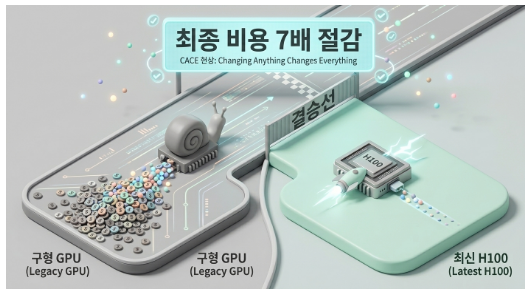



클라우드 GPU를 선택할 때 가장 흔한 실수는 '시간당 대여료'만 보고 가장 싼 머신을 고르는 것입니다.

**실험당 비용(Cost per Experiment)으로 생각하세요:**


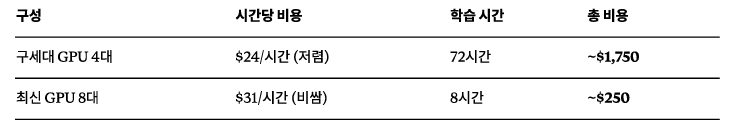

동일한 실험인데 총비용이 7배 차이가 납니다. 성능이 뛰어난 GPU를 사용하면 학습 시간이 단축되어 전체 프로젝트 비용과 엔지니어의 대기 시간을 모두 줄일 수 있습니다.  

결론: **가장 저렴한 클라우드 업체에서 가장 성능이 좋은 GPU를 빌려 짧게 끝내는 것**이 가장 경제적인 선택입니다.


### 9.5 클라우드 제공업체 선택

**GPU 전문 스타트업 (Lambda Labs, RunPod, Vast.ai 등)**: GPU 시간당 비용이 대형 클라우드의 1/2~1/3 수준입니다. 실험과 프로토타이핑 용도로 가성비가 가장 좋습니다.

**대형 클라우드 (AWS, GCP, Azure)**: 기존 인프라 연동이 필요하거나, 엔터프라이즈 수준의 SLA와 보안이 요구되는 경우에 적합합니다. 후속 MLOps 과정에서 GCP를 직접 실습합니다.

**스팟 인스턴스(Spot Instance)**: 클라우드 업체가 남는 GPU를 최대 70~90% 할인된 가격에 제공합니다. 단, 수요가 높아지면 언제든 인스턴스가 회수될 수 있습니다. 따라서 **체크포인팅 자동화가 필수**입니다 — PyTorch Lightning이 이를 기본 지원하기 때문에, Lightning을 쓰는 것 자체가 비용 최적화 전략이 됩니다.



### 9.6 실험 관리(Experiment Management)

수십~수백 번의 실험을 수행하면, "그 좋았던 결과가 어떤 하이퍼파라미터였더라?"라는 질문에 답할 수 없게 됩니다. 주피터 노트북에 결과를 메모하는 것은 확장 불가능합니다.

**Weights & Biases (W&B)**: 현재 가장 널리 사용되는 실험 관리 도구입니다.

```python
import wandb

# 실험 초기화 — 하이퍼파라미터를 자동 기록
wandb.init(project="my-fsdl-project", config={
    "lr": 1e-3,
    "batch_size": 32,
    "architecture": "ResNet-50",
    "epochs": 10,
})

# 학습 루프 내에서 메트릭 기록
for epoch in range(10):
    train_loss = train_one_epoch()
    val_loss, val_acc = evaluate()
    wandb.log({
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "epoch": epoch
    })

wandb.finish()
```

W&B의 대시보드에서 수십 개의 실험을 한눈에 비교하고, 학습률과 성능의 상관관계를 시각적으로 분석할 수 있습니다. GPU 사용률, 메모리 사용량 같은 시스템 메트릭도 자동으로 수집됩니다.

**MLflow**: 오픈소스 대안으로, 모델 패키징과 레지스트리 기능이 강점입니다. 직접 서버를 호스팅해야 하는 번거로움이 있지만, 데이터가 외부로 나가면 안 되는 환경에서 유용합니다.



### 9.7 하이퍼파라미터 최적화(HPO)

학습률, 배치 사이즈, 히든 레이어 크기 등을 수동으로 하나씩 바꿔가며 실험하는 것은 비효율적입니다. 알고리즘에 위임하세요.

**W&B Sweeps / Optuna**: 검색 범위를 설정하면, Hyperband 같은 알고리즘이 가망 없는 실험을 조기 종료(Early Stopping)하고 성능이 좋은 실험에 자원을 집중합니다. 10개의 실험을 모두 끝까지 돌리는 대신, 초반 성능이 나쁜 실험을 5에포크 만에 멈추고 좋은 실험에 GPU 시간을 몰아주는 것입니다.

> **✅ Chapter 9 체크포인트**
> 1. GPU 선택의 3대 지표(메모리 대역폭, 연산 속도, 인터커넥트) 중 분산 학습에서 가장 중요한 것은 무엇이며, 그 이유를 "고속도로와 톨게이트" 비유로 설명할 수 있으신가요?
> 2. "시간당 비용"이 아니라 "실험당 비용"으로 GPU를 평가해야 하는 이유를 표의 숫자 예시를 활용하여 설명할 수 있으신가요?
> 3. 스팟 인스턴스를 안전하게 사용하기 위해 반드시 갖춰야 할 전제 조건은 무엇인가요?
> 4. 여러분이 실습에서 진행한 실험 중, W&B가 있었다면 어떤 점이 편리했을지 구체적으로 떠올려 보실 수 있나요?

---


**✅ Chapter 9 체크포인트**
1. GPU 선택의 3대 지표(메모리 대역폭, 연산 속도, 인터커넥트) 중 분산 학습에서 가장 중요한 것은 무엇이며, 그 이유를 "고속도로와 톨게이트" 비유로 설명할 수 있으신가요?
  - 고속도로와 톨게이트 비유:
    - 연산 속도(TFLOPS): 자동차(데이터)가 달리는 고속도로의 제한 속도입니다. 높을수록 데이터 처리 속도가 빠릅니다.
    - 메모리(VRAM): 자동차를 실어 나르는 트럭의 크기입니다. 클수록 한 번에 많은 데이터(Batch Size)를 나를 수 있습니다.
    - 인터커넥트(NVLink 등): 각 고속도로 구간(GPU)을 연결하는 톨게이트(교차로)입니다.
    - 문제점: 아무리 고속도로 제한 속도가 높고 트럭이 커도, 톨게이트가 좁고 막히면 어떻게 될까요? 트럭들은 다음 구간으로 넘어가기 위해 끝없이 줄을 서야 합니다. 분산 학습도 마찬가지입니다. GPU 자체의 연산 속도가 아무리 빨라도, GPU끼리 데이터를 주고받는 통로(인터커넥트)가 느리면 전체 학습 속도는 가장 느린 통신 속도에 맞춰져 버립니다(병목 현상). NVLink는 이 톨게이트를 수십 차선으로 확장하여 하이패스처럼 통과하게 해주는 기술입니다.

2. "시간당 비용"이 아니라 "실험당 비용"으로 GPU를 평가해야 하는 이유를 표의 숫자 예시를 활용하여 설명할 수 있으신가요?
  - 숫자 예시:
    - GPU A (저렴한 구형): 시간당 $1.00 / 1 Epoch 학습에 10시간 소요 → 총 $10.00
    - GPU B (비싼 최신형): 시간당 $3.00 / 1 Epoch 학습에 2시간 소요 → 총 $6.00

  - 결론: 시간당 단가는 B가 3배 비싸지만, 연산 속도가 5배 빠르기 때문에 실험 1회를 완료하는 데 드는 총비용은 B가 40%나 저렴합니다. 개발자의 기다리는 인건비까지 고려하면, 단가가 비싸더라도 성능이 압도적인 최신 GPU(예: A100, H100)를 짧게 사용하는 것이 전체 비용(실험당 비용) 면에서 훨씬 이득입니다.

3. 스팟 인스턴스를 안전하게 사용하기 위해 반드시 갖춰야 할 전제 조건은 무엇인가요?
  - 스팟 인스턴스는 클라우드 제공자(AWS, GCP 등)가 남는 자원을 저렴하게 빌려주는 대신, 언제든지 일방적으로 회수(종료)할 수 있는 인스턴스입니다. 이를 안전하게 사용하려면 "자동 체크포인팅(Automated Checkpointing) 및 재시작 시스템"이 완벽히 구축되어 있어야 합니다.

  - 필수 조건:
    - 빈번한 상태 저장: 학습 중 주기적으로(예: 매 Epoch 끝 또는 특정 스텝마다) 모델의 가중치(Weights)와 옵티마이저 상태(Optimizer State)를 외부 스토리지(S3 등)에 저장해야 합니다.

    - 자동 복구: 인스턴스가 강제 종료된 후 새 스팟 인스턴스가 할당되었을 때, 마지막으로 저장된 체크포인트를 자동으로 불러와(Resume) 이전에 중단된 시점부터 이어서 학습할 수 있는 스크립트가 준비되어 있어야 합니다. (PyTorch Lightning의 resume_from_checkpoint 같은 기능이 필수적입니다.)

4. 여러분이 실습에서 진행한 실험 중, W&B가 있었다면 어떤 점이 편리했을지 구체적으로 떠올려 보실 수 있나요?

  - 만약 로컬 터미널이나 단순 print문으로만 학습을 진행했다면, 이런 불편함이 있었을 것입니다. W&B가 있었다면 다음과 같은 점이 극적으로 편리해집니다.
    - 실시간 원격 모니터링: 10시간짜리 학습을 돌려놓고 퇴근했는데, Loss가 튀는지(발산하는지) 확인하려 굳이 노트북을 열고 SSH로 서버에 다시 접속할 필요 없이, 스마트폰 웹 브라우저로 W&B 대시보드에 접속해 실시간 Loss 곡선을 볼 수 있습니다.
    - 하이퍼파라미터 비교 (Sweep): 학습률을 1e-3으로 했을 때와 1e-4로 했을 때의 성능 차이를 비교하기 위해 엑셀에 수기로 적을 필요가 없습니다. W&B는 각 실험의 파라미터와 결과 지표(Accuracy 등)를 자동으로 표와 겹쳐진 그래프로 그려주어 어떤 설정이 최고 성능을 내는지 직관적으로 보여줍니다.
    - 시스템 리소스 모니터링: "GPU 메모리 부족(OOM) 에러"가 났을 때, W&B가 자동으로 기록한 시스템 메트릭 대시보드를 통해 학습 중 언제 VRAM 사용량이 치솟았는지, 온도가 너무 높지는 않았는지 원인을 쉽게 파악할 수 있습니다..



## Chapter 10. 데이터 저장과 관리의 기초



### 10.1 핵심 원칙: "데이터 탐색에 10배 더 시간을 쏟아라"

모델 성능을 높이는 가장 확실한 방법은 아키텍처를 바꾸는 것이 아니라, **데이터셋을 수정하거나 보강**하는 것입니다. 실무 ML 엔지니어의 시간 중 절반 이상은 데이터를 다루는 데 쓰입니다. 복잡한 MLOps 용어와 도구에 압도될 필요가 없습니다. 단순함을 유지하되, 데이터가 시스템을 통해 어떻게 흐르는지를 직접 느끼고 관찰하는 데 시간을 투자하세요.



### 10.2 데이터의 여정: 소스에서 GPU까지

데이터는 이미지, 텍스트, 로그, 데이터베이스 기록 등 다양한 형태로 존재합니다. 하지만 딥러닝 학습을 위해서는 결국 이 모든 데이터가 **GPU 바로 옆에 있는 로컬 파일 시스템 디스크**로 옮겨져야 합니다.

이 여정의 기반이 되는 세 가지 기둥:
- **파일 시스템(File System)**: 로컬 디스크의 파일과 폴더. 가장 기본적인 저장 단위입니다.
- **객체 저장소(Object Storage)**: AWS S3, Google Cloud Storage(GCS) 등. 무한히 확장 가능하지만 접근 속도가 느립니다.
- **데이터베이스(Database)**: 구조화된 데이터를 저장하고 쿼리하는 시스템.



### 10.3 스토리지 계층 구조와 지연 시간 — 왜 DataLoader 최적화가 중요한가

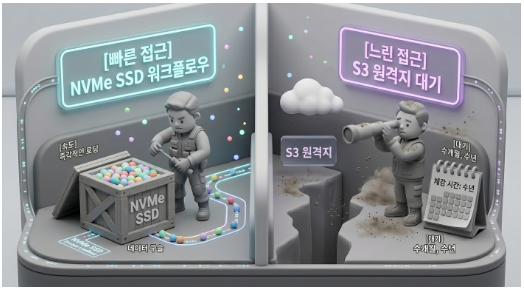



데이터를 어디에 저장하느냐에 따라 접근 속도가 천문학적으로 달라집니다. 이 차이를 직관적으로 느끼기 위해, CPU 캐시 접근(1나노초)을 인간의 1초로 환산해 봅시다:


| 위치 | 실제 시간 | 체감 시간 | 시사점 |
|---|---|---|---|
| L1/L2 캐시 | 1 ns | **1초** | GPU 연산의 이상적 속도 |
| RAM (메모리) | 100 ns | **~1.5분** | 캐시보다 100배 느림 |
| NVMe SSD 1MB | ~µs 수준 | **~2.5일** | 로컬이라도 메모리보다 훨씬 느림 |
| HDD 1MB | ~ms 수준 | **~수개월** | 물리적 회전에 의한 막대한 지연 |
| 네트워크(S3 등) | ~150 ms | **~수년** | 원격 데이터 접근의 비용 |


이 숫자를 보면 왜 데이터가 GPU 바로 옆의 NVMe SSD에 있어야 하는지 실감할 수 있습니다. 네트워크를 통해 데이터를 가져오며 학습하는 것은, 비유적으로 수년을 기다려 패킷 하나를 받는 것과 같습니다.

**`DataLoader` 최적화의 의미**: PyTorch의 `DataLoader`에서 `num_workers`를 늘리면, 여러 개의 프로세스가 미리(prefetch) 다음 배치의 데이터를 디스크에서 읽어 메모리에 올려둡니다. GPU가 현재 배치를 연산하는 동안 다음 배치가 이미 준비되어 있으므로, GPU가 데이터를 기다리며 놀지 않게 됩니다. `num_workers`의 최적값은 보통 CPU 코어 수의 절반~전체 사이이며, 실험적으로 조정해야 합니다.



### 10.4 데이터 포맷 선택 가이드

로컬 디스크에 데이터를 저장할 때 어떤 포맷을 써야 할지도 실무적으로 중요한 결정입니다.


| 포맷 | 용도 | 장점 | 단점 |
|---|---|---|---|
| Parquet | 정형 메타데이터 (URL, 라벨 등) | 압축률 높음, 열 단위 분석에 최적, Pandas와 호환 | 스트리밍 불편 |
| JSON/JSONL | 비정형 데이터, 로그, 설정 | 사람이 읽기 쉬움, 유연한 구조 | 용량이 크고 읽기 느림 |
| CSV | 간단한 표 형태 데이터 | 범용성, 어떤 도구에서든 열림 | 타입 정보 없음, 대규모에 부적합 |
| HDF5 | 대규모 다차원 수치 데이터 | 빠른 부분 읽기(슬라이싱) | 동시 쓰기 불편 |
| safetensors | 모델 가중치 | 보안, 빠른 로딩, 부분 로딩 가능 | 모델 전용 |


**실무 원칙**: 이진 데이터(이미지, 오디오, 비디오)는 객체 저장소(S3)에 업로드하고, 데이터베이스에는 해당 파일의 **URL만** 저장하세요. 데이터베이스에 이진 데이터를 직접 넣으면 DB 성능이 급격히 저하되고, 백업과 복제가 어려워집니다.



### 10.5 데이터베이스의 기초: OLTP vs OLAP

ML 프로젝트에서 데이터베이스를 사용하는 이유는 단순합니다 — 데이터를 구조적으로 저장하고, SQL 쿼리로 빠르게 조회하기 위해서입니다.

**OLTP (Online Transaction Processing)**: 행(Row) 지향 데이터베이스. "사용자 A의 모든 주문을 조회하라"처럼 특정 레코드를 빠르게 읽고 쓰는 데 최적화되어 있습니다.
- 추천 도구: **Postgres** (가장 권장되는 오픈소스 DB, JSON 쿼리까지 지원), **SQLite** (파일 하나로 구성, 프로토타이핑에 최적)

**OLAP (Online Analytical Processing)**: 열(Column) 지향 데이터베이스. "지난 30일간 전체 이미지의 평균 해상도를 계산하라"처럼 대량 데이터를 집계하고 분석하는 데 최적화되어 있습니다. 열 단위로 데이터를 저장하므로, 특정 컬럼만 읽어오면 되어 분석 속도가 매우 빠르고 압축률도 높습니다.

**데이터 레이크하우스**: 비구조화 데이터를 그대로 수집(Extract-Load)한 뒤 필요할 때 변환(Transform)하는 현대적 구조입니다. Snowflake, Databricks가 대표적입니다. 후속 MLOps 과정에서 BigQuery를 통해 직접 실습합니다.

**MLOps 도구와 데이터베이스**: 실제로 여러분이 사용하는 많은 도구의 핵심은 데이터베이스입니다. W&B는 "실험 데이터의 데이터베이스"이고, Hugging Face Hub는 "모델의 데이터베이스"이며, Label Studio는 "라벨의 데이터베이스"입니다.



> **✅ Chapter 10 체크포인트**
> 1. 스토리지 계층 구조의 지연 시간 차이가 `DataLoader`의 `num_workers` 설정에 어떤 영향을 미치는지 설명할 수 있으신가요?
> 2. "이진 데이터는 S3에, URL만 DB에"라는 원칙의 이유를 설명할 수 있으신가요? 이 원칙을 어겼을 때 어떤 문제가 발생하나요?
> 3. OLTP와 OLAP의 차이를 "행 지향 vs 열 지향"의 관점에서, 각각 어떤 쿼리에 적합한지 예시와 함께 설명할 수 있으신가요?

---


**✅ Chapter 10 체크포인트**
1. 스토리지 계층 구조의 지연 시간 차이가 `DataLoader`의 `num_workers` 설정에 어떤 영향을 미치는지 설명할 수 있으신가요?
  - 스토리지 계층에서 하위로 갈수록(RAM → NVMe SSD → HDD → S3 네트워크) 지연 시간(Latency)은 기하급수적으로 늘어납니다. 이 물리적인 지연 시간은 PyTorch의 DataLoader에서 병렬 데이터 로딩을 담당하는 num_workers 설정에 직접적인 영향을 미칩니다.
    - 빠른 스토리지 (예: 로컬 NVMe SSD, RAM 캐시): * 데이터를 읽어오는 속도가 GPU가 연산하는 속도를 충분히 따라갈 수 있습니다.
      - num_workers를 적당히(예: 2~4)만 설정해도 GPU에 데이터가 끊임없이 공급됩니다. 불필요하게 worker를 너무 많이 늘리면 오히려 CPU의 컨텍스트 스위칭(Context Switching) 오버헤드 때문에 전체 속도가 느려질 수 있습니다.

  - 느린 스토리지 (예: HDD, 외부 S3 버킷 직접 마운트):
    - 디스크 헤드가 물리적으로 움직이거나(HDD), 네트워크 통신을 기다려야 하므로(S3) 데이터 한 건을 가져오는 데 엄청난 시간이 걸립니다.
    - 이때 num_workers가 부족하면 GPU는 데이터가 올 때까지 놀게 됩니다(GPU Starvation). 따라서 느린 스토리지 환경에서는 더 많은 num_workers를 할당(예: 8~16 이상)하여, 여러 CPU 프로세스가 미리미리 느린 I/O 작업을 병렬로 대기하고 가져오도록 만들어야 GPU의 연산 공백을 최소화할 수 있습니다.
    - 단, 가장 이상적인 해결책은 학습 전 데이터를 가장 빠른 로컬 스토리지로 복사(Staging)해 두는 것입니다.

2. "이진 데이터는 S3에, URL만 DB에"라는 원칙의 이유를 설명할 수 있으신가요? 이 원칙을 어겼을 때 어떤 문제가 발생하나요?
    - B짜리 이미지들이 DB에 쌓이면 순식간에 테라바이트 단위로 커지며 인프라 유지 비용이 폭증합니다.
    - 캐시 메모리(Buffer Pool) 오염: DB는 자주 찾는 데이터를 RAM에 올려두어(캐싱) 검색 속도를 높입니다. 거대한 이미지 데이터가 DB를 통과하면, 정작 메모리에 있어야 할 중요한 '인덱스' 데이터들이 쫓겨나게 되어 전체 서비스의 쿼리 속도가 치명적으로 느려집니다.
    - 백업/복구 시간 지연: DB 백업 시 수십 GB, 수 TB의 이미지 데이터까지 함께 백업해야 하므로, 장애 발생 시 시스템을 복구하는 데 몇 분이면 될 일이 수십 시간이 걸리게 됩니다.

3. OLTP와 OLAP의 차이를 "행 지향 vs 열 지향"의 관점에서, 각각 어떤 쿼리에 적합한지 예시와 함께 설명할 수 있으신가요?
- 데이터베이스가 디스크에 데이터를 물리적으로 어떻게 기록해 두느냐의 차이입니다.

  - OLTP (온라인 트랜잭션 처리) = 행 지향(Row-oriented)
  저장 방식: 데이터가 가로(Row) 단위로 묶여서 디스크에 연속적으로 저장됩니다. [고객A_ID, 고객A_이름, 고객A_나이], [고객B_ID, 고객B_이름...]
  - 적합한 쿼리 (특정 객체의 전체 정보 조회/수정): * "고객 A의 프로필 정보를 화면에 띄워줘!" (SELECT * FROM users WHERE id='A')
    - 디스크에서 고객 A가 시작되는 위치만 찾으면, 이름, 나이, 주소 등 관련된 모든 정보를 한 번의 디스크 읽기(I/O)로 한꺼번에 가져올 수 있어 매우 빠릅니다. (서비스 백엔드용)

  - OLAP (온라인 분석 처리) = 열 지향(Column-oriented)
    - 저장 방식: 데이터가 세로(Column) 단위로 묶여서 디스크에 연속적으로 저장됩니다. [고객A_ID, 고객B_ID...], [고객A_이름, 고객B_이름...], [고객A_나이, 고객B_나이...]
    - 적합한 쿼리 (특정 속성의 대규모 집계/통계):
    - "이번 달 가입한 모든 고객의 '평균 나이'를 구해줘!" (SELECT AVG(age) FROM users)
    - 행 지향 DB라면 나이를 구하기 위해 쓸데없이 이름, ID, 주소까지 전부 디스크에서 읽어야 합니다. 하지만 열 지향 DB(예: BigQuery, Redshift, Parquet 포맷)는 오직 '나이' 컬럼이 모여있는 디스크 블록만 딱 떼어서 읽어오면 되므로 디스크 I/O가 획기적으로 줄어들어 압도적으로 빠릅니다. (데이터 분석 및 ML 피처 추출용)


## Chapter 11. 데이터 레이블링과 품질 관리



### 11.1 레이블링을 최소화하는 전략

가장 좋은 레이블링 전략은 **레이블링을 최대한 하지 않는 것**입니다. 수동 레이블링은 비용이 많이 들고 오류가 발생하기 쉽기 때문입니다. 다행히 레이블링 없이도 모델을 학습시킬 수 있는 다양한 전략이 존재합니다.

**(1) 자기주도 학습(Self-supervised Learning)**: 여러분이 배운 LLM의 Pretraining이 바로 이것입니다. GPT가 "다음 토큰 예측"으로 학습하고, BERT가 "마스킹된 단어 맞추기"로 학습하는 것처럼, 데이터 자체의 구조를 활용하여 별도의 레이블 없이 학습합니다. 비전 분야에서도 이미지의 일부를 마스킹하고 복원하는 MAE(Masked Autoencoder)나, 두 가지 다른 변환을 적용한 이미지가 같은 원본에서 왔음을 학습하는 대조 학습(Contrastive Learning)이 널리 사용됩니다.

**(2) 데이터 증강(Data Augmentation)**: 하나의 원본 데이터를 변형하여 여러 학습 데이터를 만드는 기법입니다. 핵심은 데이터의 본질적 의미는 유지하면서 표면적 특성만 바꾸는 것입니다.
- 비전: 밝기 조절, 대비 변경, 크롭, 회전, 뒤집기, 색상 지터링
- 텍스트: 유의어 교체, 역번역(한국어→영어→한국어), 문장 순서 변경
- 음성: 속도 조절, 잡음 추가, 피치 변경

**(3) 합성 데이터(Synthetic Data)**: 알고리즘이나 생성 모델로 데이터를 직접 만듭니다. 생성 시점에 이미 정답을 알고 있으므로 레이블링 비용이 '0'입니다.

2026년 현재, **LLM을 이용한 합성 데이터 생성**이 대규모 Fine-tuning 데이터셋 구축의 핵심 전략으로 떠올랐습니다. 예를 들어, "고객 문의에 대한 친절한 응답 1000개를 생성하라"라는 프롬프트로 GPT-4o에게 학습 데이터를 만들게 할 수 있습니다. 물론 합성 데이터의 품질을 검증하는 단계는 반드시 필요합니다.

**(4) 사용자 피드백을 레이블로 전환**: Day 1에서 배운 데이터 플라이휠의 실체입니다. 사용자의 클릭, 스킵, 수정, 평점, "좋아요" 등의 행동 자체가 암묵적 레이블이 됩니다. 구글 포토가 사용자에게 "이 사람이 같은 사람인가요?"라고 물어 앨범 정리를 도우면서 동시에 얼굴 인식 모델의 학습 데이터를 확보하는 것이 대표적인 예입니다.



### 11.2 수동 레이블링이 필요할 때의 실무 프로세스

위 전략들을 모두 활용해도, 결국 수동 레이블링이 필요한 시점이 오게 됩니다. 이때 체계적인 프로세스 없이 레이블링을 시작하면, 비용은 많이 들면서 품질은 낮은 데이터셋이 만들어집니다.

**1단계 — 직접 레이블링하며 데이터 이해하기**: 외주를 주기 전에, 엔지니어가 직접 최소 100개 이상의 데이터를 레이블링해 보세요. 이 과정에서 "이 케이스는 긍정인가 부정인가?"라는 모호한 상황들이 발견되고, 이를 해결하면서 가이드라인이 구체화됩니다.

**2단계 — 가이드라인(Rulebook) 작성**: 단순해 보이는 작업도 보는 사람에 따라 해석이 달라집니다. "바위 뒤에 숨어 머리만 보이는 여우가 있다면, 머리만 바운딩 박스를 치는가? 바위 뒤의 몸체까지 추측해서 치는가?" 이런 모호함을 사전에 정의하지 않으면, 레이블러마다 다른 기준으로 작업하게 됩니다.

**3단계 — 골드 표준(Gold Standard) 데이터셋 구축**: 엔지니어가 직접 레이블링한 소량(보통 200~500개)의 기준 데이터셋입니다. 레이블러의 작업 결과를 이 골드 표준과 비교하여 품질을 평가합니다.

**4단계 — 평가자 간 일치도(Inter-annotator Agreement) 측정**: 여러 명이 같은 데이터를 레이블링했을 때, Cohen's Kappa나 Fleiss' Kappa 같은 지수로 일치도를 측정합니다. 일치도가 낮다면 가이드라인이 모호하거나 태스크 자체의 정의가 잘못된 것입니다.

**5단계 — 레이블링 도구와 외주 선택**:
- **Label Studio**: 오픈소스, 자체 호스팅 가능. 텍스트, 이미지, 오디오 등 다양한 데이터 타입 지원.
- **Scale.ai**: 상용 서비스. 소프트웨어 + 인력 + QA를 한꺼번에 제공. 예산이 충분하다면 가장 편리한 선택.
- **크라우드 소싱(MTurk 등)**: 비용은 저렴하지만 QA 관리 오버헤드가 크므로, 대규모 프로젝트에서만 권장됩니다.



### 11.3 능동적 학습(Active Learning) — 레이블링 효율 극대화

모든 데이터를 레이블링하는 대신, **모델이 가장 확신이 없는(Uncertainty) 데이터만 골라 레이블링을 요청**하는 전략입니다.

작동 방식: 소량의 레이블된 데이터로 초기 모델을 학습 → 남은 데이터에 대해 예측 → 예측 불확실성이 높은 상위 N개를 인간에게 레이블링 요청 → 모델 재학습 → 반복

이를 통해 동일한 레이블링 예산으로 더 큰 성능 향상을 얻을 수 있습니다.



### 11.4 약지도 학습(Weak Supervision)과 Snorkel

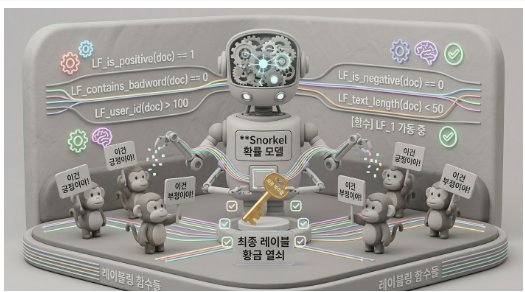



수만 개의 데이터를 일일이 레이블링하는 대신, 우리가 가진 **휴리스틱(직관적 규칙)을 코드로 변환**하여 대략적인 레이블을 대량으로 생성하는 접근법입니다.

기본 아이디어: "텍스트에 'wonderful'이 있으면 긍정(1), 'terrible'이 있으면 부정(0)"같은 단순한 규칙(레이블링 함수)을 여러 개 작성합니다. 각 함수는 완벽하지 않지만(즉, '약한' 신호이지만), 수백만 개의 데이터에 즉시 적용할 수 있습니다.

```python
# 감성 분석을 위한 레이블링 함수 예시
def lf_positive_keyword(text):
    return 1 if "wonderful" in text.lower() else -1  # -1 = 기권(모름)

def lf_negative_keyword(text):
    return 0 if "terrible" in text.lower() else -1

def lf_sentiment_model(text):
    # 기존에 학습된 약한 모델의 예측값을 활용
    score = simple_sentiment_model.predict(text)
    return 1 if score > 0.8 else (0 if score < 0.2 else -1)
```

**Snorkel의 지능형 결합**: 여러 레이블링 함수가 서로 충돌할 때(예: 한 함수는 긍정, 다른 함수는 부정이라고 판단), Snorkel의 확률 모델이 각 함수의 정확도와 상관관계를 자동으로 학습하여 노이즈가 적은 최종 레이블을 생성합니다.

**약지도 학습의 가장 큰 장점 — 유지보수성**: 수동 레이블링의 치명적 단점은 데이터 스키마가 변했을 때(예: "긍정/부정"에서 "긍정/중립/부정"으로 변경) 모든 데이터를 다시 레이블링해야 한다는 점입니다. 하지만 약지도 학습 환경에서는 **레이블링 함수(코드)만 수정하고 다시 실행**하면 수백만 개의 레이블을 즉시 갱신할 수 있습니다.



> **✅ Chapter 11 체크포인트**
> 1. 레이블링을 최소화하는 4가지 전략(자기주도 학습, 증강, 합성 데이터, 사용자 피드백)을 각각 한 문장으로 요약하고, 자신의 프로젝트에 적용 가능한 것을 골라보실 수 있나요?
> 2. 수동 레이블링의 5단계 프로세스 중 "골드 표준 데이터셋"은 왜 필요한가요? 이것 없이 외주를 맡기면 어떤 문제가 생기나요?
> 3. 약지도 학습이 수동 레이블링 대비 갖는 가장 큰 장점을 "유지보수" 관점에서 설명해 보세요. 레이블 체계가 변경되었을 때 각각 어떤 일이 벌어지나요?
> 4. LLM을 이용한 합성 데이터 생성이 효과적인 상황과 주의해야 할 점은 무엇인가요?

---


**✅ Chapter 11 체크포인트**
1. 레이블링을 최소화하는 4가지 전략(자기주도 학습, 증강, 합성 데이터, 사용자 피드백)을 각각 한 문장으로 요약하고, 자신의 프로젝트에 적용 가능한 것을 골라보실 수 있나요?
    - 자기지도 학습 (Self-supervised Learning): 입력 데이터 자체의 일부를 가리거나 변형한 뒤, 이를 복원하는 과정을 통해 스스로 정답을 찾아 학습하는 방법입니다.
    - 데이터 증강 (Data Augmentation): 기존에 구축된 소량의 정답 데이터에 노이즈를 추가하거나 변형을 가해 데이터의 절대적인 양을 부풀리는 방법입니다.
    - 합성 데이터 (Synthetic Data): 시뮬레이터나 생성형 모델(LLM 등)을 활용해 현실에 존재하지 않지만 통계적으로 유효한 가상의 데이터를 새로 만들어내는 방법입니다.
    - 사용자 피드백 (User Feedback): 실제 서비스 환경에서 사용자의 클릭, 체류 시간, 검색어 수정 등의 행동 로그를 수집하여 이를 암묵적인 정답 데이터로 활용하는 방법입니다.

2. 수동 레이블링의 5단계 프로세스 중 "골드 표준 데이터셋"은 왜 필요한가요? 이것 없이 외주를 맡기면 어떤 문제가 생기나요?
    - 필요성: 이 데이터는 다수의 작업자(Annotator)들을 교육하고, 이들의 작업 품질(작업자 간 일치도)을 평가하며, 최종 모델의 성능을 정확히 측정하는 테스트 벤치마크로 사용됩니다.

    - 외주 시 문제점: 명확한 API 명세서나 테스트 코드 없이 여러 작업자에게 모듈 개발을 분배하는 것과 같습니다. 작업자마다 주관적인 판단 기준이 개입되어 데이터의 일관성이 심각하게 훼손되며, 결국 'Garbage In, Garbage Out'으로 인해 모델은 제대로 된 특징을 학습할 수 없게 됩니다.

3. 약지도 학습이 수동 레이블링 대비 갖는 가장 큰 장점을 "유지보수" 관점에서 설명해 보세요. 레이블 체계가 변경되었을 때 각각 어떤 일이 벌어지나요?
    - 수동 레이블링 시: 레이블 체계가 변경되면(예: 카테고리 분리 통폐합), 수십만 건의 DB 레코드를 사람이 일일이 다시 열어보고 수동으로 업데이트해야 합니다. 엄청난 시간과 비용이 소모됩니다.
    - 약지도 학습 시: 코드로 짜여진 레이블링 함수의 조건문 로직만 수정한 뒤 파이프라인 스크립트를 재실행하면 됩니다. 즉각적으로 전체 데이터셋에 새로운 체계가 반영되므로, 확장성과 유지보수성이 압도적으로 뛰어납니다.

4. LLM을 이용한 합성 데이터 생성이 효과적인 상황과 주의해야 할 점은 무엇인가요?
    - 효과적인 상황: 특정 도메인의 데이터가 극도로 부족한 초기 단계이거나, 현실에서는 수집하기 힘든 희귀 케이스(Edge case) 및 보안 민감성 데이터(PII)를 학습시켜야 할 때 매우 효과적입니다.

    - 주의할 점: LLM 특유의 '환각(Hallucination)' 현상이 데이터에 섞여 들어갈 수 있습니다. 또한, 생성된 데이터가 너무 정제되어 있어 실제 환경의 복잡하고 지저분한 '노이즈(Noise)'나 텍스트의 다양성을 충분히 반영하지 못할 수 있습니다. 이는 실전 배치 시 모델의 성능 저하(Overfitting)를 유발할 수 있으므로, 반드시 사람의 검수 로직이나 필터링 시스템을 병행해야 합니다.


## Chapter 12. 데이터 버전 관리와 워크플로우 자동화



### 12.1 왜 데이터를 버전 관리해야 하는가

ML 시스템에서는 **'코드 + 데이터 = 모델'** 이라는 공식이 성립합니다. 전통적인 소프트웨어에서는 코드만 관리하면 되지만, ML에서는 코드가 같아도 데이터가 다르면 완전히 다른 모델이 나옵니다.

구체적인 시나리오를 떠올려 봅시다: 배포된 모델의 성능이 갑자기 떨어졌습니다. 코드를 지난주 버전으로 롤백했는데도 성능이 복구되지 않습니다. 왜? 그 사이에 데이터셋이 업데이트되었기 때문입니다. 하지만 데이터가 버전 관리되지 않았다면, "지난주의 정확한 데이터 상태"를 재현할 방법이 없습니다.



### 12.2 데이터 버전 관리의 4단계

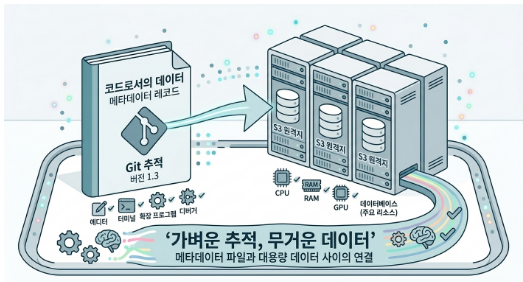



**Level 0 — 무관리(Unversioned)**: 데이터가 로컬 파일이나 S3에 저장되어 있지만, 어떤 시점에 어떤 데이터로 모델을 학습시켰는지 기록이 없습니다. 가장 위험한 상태이며, 놀랍도록 많은 팀이 이 단계에 머물러 있습니다.

**Level 1 — 스냅샷(Snapshotting)**: 학습할 때마다 데이터 전체를 복사하여 날짜별 폴더(`data/2026-04-09/`)에 저장합니다. 재현성은 확보되지만, 10GB 데이터셋을 매번 복사하면 저장 공간이 빠르게 소진되고, 코드 버전과 데이터 버전이 별개로 움직여 관리가 번거롭습니다.

**Level 2 — 코드로서의 데이터(추천)**: 이진 데이터는 S3에, 메타데이터(URL + 라벨)는 Parquet/JSON 파일로 만들어 **Git LFS**로 관리합니다. 비유하자면, "오디오 파일 수천 개를 일일이 관리하는 대신, 그 파일들의 주소가 적힌 '장부'를 Git으로 관리하는 것"과 같습니다. 장부를 지난주 버전으로 되돌리면, 자동으로 지난주의 데이터셋이 복원됩니다.

**Level 3 — 전문 도구(DVC)**: Data Version Control의 약자입니다. 대용량 파일의 해시(Hash) 값을 Git으로 추적하고, 실제 데이터는 원격 저장소(S3, GCS)와 동기화합니다. 단순히 데이터 상태만 저장하는 것이 아니라, 특정 데이터가 **어떤 전처리 과정을 거쳐 생성되었는지 리니지(Lineage)**까지 기록합니다. `dvc run` 명령어로 데이터 생성부터 모델 학습까지의 모든 단계를 하나의 재현 가능한 파이프라인으로 묶을 수 있습니다.

**실무 권장**: 대부분의 팀에는 **Level 2가 가장 실용적**입니다. Level 3은 데이터 파이프라인이 복잡해지거나, 대용량 파일 추적이 빈번해진 후에 도입해도 늦지 않습니다. 가장 중요한 것은 **Level 0에서 벗어나는 것**입니다.



### 12.3 데이터 처리 워크플로우 자동화

ML 프로젝트가 실험 단계를 넘어 서비스로 나아가면, 매일 혹은 매시간 반복되는 데이터 처리를 자동화해야 합니다.

**구체적 시나리오**: 매일 밤, 새로 올라온 사진들의 인기도를 예측하는 모델을 재학습시켜야 합니다. 이를 위해서는: (1) 데이터베이스에서 사진 메타데이터 추출 → (2) 사용자 로그에서 특징 생성 → (3) 기존 분류기로 사진 스타일 분석 → (4) 최종 모델 학습. 이 작업들은 순서가 있고, 앞 단계가 실패하면 뒷 단계를 실행해서는 안 됩니다.

**DAG(유향 비순환 그래프)**: 이런 복잡한 순서와 의존성을 관리하기 위한 개념입니다. 작업들이 한 방향으로 흐르며, 서로 순환하지 않는 구조입니다.

**주요 자동화 도구**:
- **Apache Airflow**: 업계 표준. 파이썬 코드로 DAG를 정의하고, 실패한 작업을 자동 재시도하며, 작업 상태를 대시보드에서 모니터링합니다.
- **Prefect**: Airflow의 복잡함을 개선한 현대적 대안. 코드 작성이 더 직관적입니다.
- **Dagster**: 작업 순서뿐 아니라 '데이터 자체'의 흐름에 집중하는 접근법을 취합니다.



### 12.4 "오버 엔지니어링을 경계하라"

워크플로우 자동화에서 가장 중요한 조언입니다.

한때 하둡(Hadoop)이 유행할 때, 대량의 텍스트 파일을 처리하기 위해 하둡 클러스터를 구축한 사람이 있었습니다. 결과: 26분. 동일한 작업을 단순한 유닉스(Unix) 명령어 조합으로 처리하자: **70초**. 유닉스 명령어는 이미 파이프라인과 병렬 처리가 극도로 최적화되어 있습니다.

**실무 원칙**: 수만 대의 서버를 운영하는 대기업이 아니라면, 32코어 PC 한 대에서 돌아가는 단순한 파이썬 스크립트가 수천만 원짜리 분산 처리 인프라보다 더 빠르고 안정적일 수 있습니다. 도구가 존재한다고 해서 반드시 써야 하는 것은 아닙니다.

후속 MLOps 과정에서 Airflow를 직접 실습합니다. 지금은 **"왜 워크플로우 자동화가 필요한지"** 라는 동기만 이해하면 충분합니다.



> **✅ Chapter 12 체크포인트**
> 1. 데이터 버전 관리의 4단계 중 자신의 현재 프로젝트는 어느 레벨에 해당하나요? 한 단계 올리려면 구체적으로 무엇을 해야 하나요?
> 2. "코드 + 데이터 = 모델"이라는 공식에서, 데이터 버전 관리 없이 모델을 롤백하려 할 때 어떤 문제가 발생하는지 구체적인 시나리오를 그려보실 수 있나요?
> 3. Level 2("코드로서의 데이터")의 "장부" 비유를 자신의 언어로 다시 설명할 수 있으신가요?
> 4. 워크플로우 자동화가 필요해지는 시점은 언제인가요? "단순한 파이썬 스크립트"로 충분한 경우와, Airflow 같은 전문 도구가 필요한 경우를 구분할 수 있으신가요?

---



**✅ Chapter 12 체크포인트**
1. 데이터 버전 관리의 4단계 중 자신의 현재 프로젝트는 어느 레벨에 해당하나요? 한 단계 올리려면 구체적으로 무엇을 해야 하나요?
    - Level 0 (무관리): data_final.csv, data_real_final.csv 처럼 파일명으로 관리하는 상태.
    - Level 1 (스냅샷): 데이터 전체를 압축하여 AWS S3나 로컬 백업 서버에 날짜별로 저장하는 상태.
    - Level 2 (코드로서의 데이터): DVC(Data Version Control) 등을 사용해 데이터의 메타데이터(해시값)만 Git으로 관리하는 상태.
    - Level 3 (완전 자동화): Feature Store와 연동되어 데이터 변경 시 파이프라인이 자동 트리거되는 상태.

2. "코드 + 데이터 = 모델"이라는 공식에서, 데이터 버전 관리 없이 모델을 롤백하려 할 때 어떤 문제가 발생하는지 구체적인 시나리오를 그려보실 수 있나요?

  - "코드 + 데이터 = 모델"이라는 머신러닝의 대전제 하에서, 데이터 버전 관리가 없다면 치명적인 재현성(Reproducibility) 문제가 발생합니다.
    - 시나리오: 새롭게 배포한 AI 모델이 프로덕션 환경에서 엉뚱한 예측을 뱉어내기 시작하여, 긴급히 어제 버전의 모델로 롤백해야 하는 상황입니다. Git을 통해 모델의 아키텍처 코드는 어제 상태로 완벽히 되돌렸습니다. 하지만, 어제 모델을 학습시킬 때 사용했던 '당시의 데이터셋' 원본 파일이 오늘 아침 새로운 데이터로 덮어씌워져 버렸습니다.
    - 결과: 코드는 남아있지만 당시의 데이터가 없기 때문에, 어제 배포했던 것과 정확히 동일한 가중치를 가진 모델을 다시 빌드할 방법이 영영 사라집니다. 백엔드에서 소스코드는 이전 커밋으로 돌렸는데, DB의 특정 시점 데이터가 완전히 날아가 버려 전체 시스템 상태를 복구할 수 없는 것과 같습니다.

3. Level 2("코드로서의 데이터")의 "장부" 비유를 자신의 언어로 다시 설명할 수 있으신가요?
  - 수십, 수백 기가바이트에 달하는 데이터를 코드처럼 매번 Git 리포지토리에 커밋할 수는 없습니다. 여기서 '장부(Ledger)'의 개념이 등장합니다.

  - 물류 창고에 쌓인 무거운 화물(데이터)을 이동하거나 복제하는 대신, 관리자는 "A 구역 3번 선반에 무게 500kg짜리 상자(해시값)가 있다"라고 적힌 얇은 장부(메타데이터 텍스트 파일)만 들고 다닙니다. 이 장부만 Git에 올려 버전 관리를 하면, 코드를 체크아웃할 때 장부에 적힌 주소표를 보고 외부 스토리지(S3 등)에서 정확히 해당 시점의 데이터만 알맞게 당겨올(Pull) 수 있습니다. 데이터의 본체와 메타데이터를 분리하는 것이 핵심입니다.

4. 워크플로우 자동화가 필요해지는 시점은 언제인가요? "단순한 파이썬 스크립트"로 충분한 경우와, Airflow 같은 전문 도구가 필요한 경우를 구분할 수 있으신가요?
  - 단순한 파이썬 스크립트 (Cron 기반)로 충분한 경우:데이터 수집 $\rightarrow$ 전처리 $\rightarrow$ 학습으로 이어지는 파이프라인이 선형적이고 단순할 때입니다. 작업 실패 시 처음부터 다시 돌려도 부담이 없고, 전체 작업 시간이 짧으며, 단일 서버에서 모든 과정이 처리된다면 굳이 무거운 도구를 붙일 필요가 없습니다.
  - Airflow 같은 전문 오케스트레이션 도구가 필요한 시점:
    - 복잡한 의존성 (DAG): "A 데이터 수집과 B 데이터 수집이 모두 완료되어야만 C 전처리를 시작한다" 같은 복잡한 조건 분기가 생길 때.
    - 재시도 및 부분 실행 (Fault Tolerance): 10시간짜리 파이프라인 중 8시간 지점에서 에러가 났을 때, 처음부터가 아니라 실패한 지점부터 재시도(Retry)해야 할 때.
    - 분산 처리 및 모니터링: 여러 대의 서버나 클러스터에서 작업을 분산 실행해야 하고, 각 스텝의 소요 시간과 리소스 상태를 시각적으로 모니터링해야 할 때 필수적입니다.


## Day 2 정리

오늘 우리는 ML 프로젝트의 "보이지 않는 90%"를 다루었습니다. 화려한 모델 아키텍처 뒤에 있는 개발 환경, 인프라, 그리고 데이터 관리 — 이것들이 프로젝트의 실제 속도와 품질을 결정합니다.

**핵심 메시지:**

1. **주피터에서 벗어나세요.** 탐색은 노트북에서, 핵심 코드는 `.py` 모듈에서 관리하는 하이브리드 워크플로우로 전환해야 합니다. VS Code + 원격 개발이 이를 가능하게 합니다.

2. **PyTorch를 넘어 PyTorch Lightning으로.** 여러분이 작성하던 학습 루프를 구조화하면, 분산 학습·혼합 정밀도·체크포인팅이 파라미터 한 줄의 변경으로 가능해집니다. 이것은 단순한 편의가 아니라, 스팟 인스턴스 활용 같은 비용 최적화의 전제 조건이기도 합니다.

3. **GPU 비용은 "실험당"으로 계산하세요.** 시간당 비싼 최신 GPU가 총비용으로는 오히려 저렴합니다. 스팟 인스턴스 + 체크포인팅 자동화가 비용 최적화의 핵심입니다.

4. **데이터는 코드만큼 중요하게 관리하세요.** 데이터 버전 관리(최소 Level 2), 레이블링 가이드라인, 골드 표준 데이터셋이 모델 품질의 진정한 기반입니다. Level 0에서 벗어나는 것이 첫 번째 과제입니다.

5. **레이블링은 엔지니어링입니다.** 자기주도 학습, 합성 데이터, 약지도 학습으로 수동 레이블링을 최소화하고, 사용자 피드백이 자연스럽게 레이블이 되는 플라이휠을 설계하세요.

**내일(Day 3) 예고:** 오늘 구축한 인프라 위에서 모델을 테스트하고, 트러블슈팅하고, 성능을 최적화하는 전략을 다룹니다. "구동되게 만들고(Make it run), 빠르게 만들고(Make it fast), 올바르게 만드는(Make it right)" 3단계 접근법을 학습합니다.

---



**✅ Day 2 통합 체크포인트 — 오늘 배운 것을 하나로 꿰기**

1. **환경 점검**: 여러분이 지금까지 실습에 사용한 환경을 떠올려 보세요. 재현 가능한 환경 구축(결정적 빌드)이 되어 있었나요? 팀원에게 동일한 환경을 전달하려면 어떤 파일들이 필요한가요?
    - 현재 상태 점검: 단순히 pip install로 패키지를 설치했다면 재현성이 보장되지 않습니다. 패키지의 하위 의존성이 업데이트되면서 모델 연산 결과가 달라질 수 있기 때문입니다.

    - 팀원에게 전달해야 할 핵심 파일:
      - 패키지 명세서: requirements.txt (버전 명시 필수, 예: torch==2.1.0), 또는 더 엄격한 의존성 관리를 위한 Pipfile.lock, poetry.lock
      - OS 및 시스템 라이브러리: CUDA 버전과 OS 환경까지 통제하기 위한 Dockerfile

2. **코드 리팩토링 계획**: 지금까지 작성한 PyTorch 학습 코드 중 하나를 골라, Lightning으로 리팩토링한다면 어떤 부분이 `LightningModule`로, 어떤 부분이 `Trainer` 설정으로 분리될지 구체적으로 구상해 보세요. `training_step`, `validation_step`, `configure_optimizers` 각각에 무엇이 들어가나요?

    - LightningModule (모델 로직의 캡슐화):
      - training_step: 배치 데이터를 받아 모델에 통과시키고(Forward), 손실(Loss)을 계산하여 반환하는 핵심 학습 로직이 들어갑니다.
      - validation_step: 검증 데이터셋에 대한 정확도, F1 Score 등의 평가지표를 계산하고 로깅하는 로직이 위치합니다.
      - configure_optimizers: 학습에 사용할 옵티마이저(Adam, SGD 등)와 학습률 스케줄러(Learning Rate Scheduler)를 정의합니다.

    - Trainer (엔지니어링 로직):
      - 에포크(Epoch) 횟수, 사용할 GPU 기기 수 설정 (accelerator="gpu", devices=1), 분산 학습 설정, 모델 체크포인트 저장, 조기 종료(Early Stopping) 등 인프라와 관련된 모든 제어를 담당합니다.

3. **인프라 설계**: Day 1에서 기획한 ML 프로젝트를 실행한다면, GPU는 무엇을 선택하고, 클라우드는 어디를 쓰며, 실험 관리는 어떤 도구를 사용할지 구체적으로 계획해 보세요. 예상 비용은 얼마인가요?
    - GPU 선택 및 클라우드:
      - 초기 프로토타이핑: 비용 효율성이 높은 RunPod이나 Lambda Labs에서 RTX 3090/4090 인스턴스를 대여하여 빠르게 실험합니다. (시간당 약 $0.3 ~ $0.5 수준)
      - 본격적인 스케일업: 대용량 학습이 필요해지면 AWS SageMaker나 GCP Vertex AI 환경에서 A10G 또는 A100 GPU로 전환합니다.

    - 실험 관리 도구: 모델의 하이퍼파라미터 변경 이력과 Loss 그래프를 실시간으로 추적하기 위해 Weights & Biases (W&B)를 도입하는 것이 표준적이고 직관적입니다.


4. **데이터 전략**: 같은 프로젝트의 데이터를 어떻게 확보할 것인가요? 레이블링을 최소화하는 전략 중 적용 가능한 것은 무엇이며, 데이터 버전 관리는 어느 레벨부터 시작할 것인가요?
    - 데이터 확보 및 레이블링 최소화:
      - 콜드 스타트 단계에서는 LLM을 활용한 합성 데이터(Synthetic Data) 생성으로 기초 체력을 다집니다. 이후 휴리스틱 규칙을 코드로 작성하는 약지도 학습(Weak Supervision)을 적용해 수동 레이블링 비용을 최소화합니다.

    - 데이터 버전 관리:
      - 파일명 기반의 관리는 배제하고, 즉시 Level 2 (DVC + S3 버킷) 단계부터 시작하는 것이 기술 부채를 막는 가장 빠른 길입니다. 데이터의 메타데이터(해시값)만 Git으로 추적하여 소스 코드와 데이터를 동기화합니다.


5. **비용 시뮬레이션**: 위 프로젝트의 학습에 필요한 GPU 시간을 대략적으로 추산하고, 클라우드 비용을 "시간당"과 "실험당" 두 관점에서 비교해 보세요. 스팟 인스턴스를 쓸 수 있는 조건이 갖춰져 있나요?
    - 스팟 인스턴스(Spot Instance) 활용: 온디맨드 대비 60~70% 저렴하지만, 클라우드 사업자의 리소스 상황에 따라 사전 경고(통상 2분 전) 후 인스턴스가 강제 종료될 수 있습니다.
    - 활용 필수 조건 (Fault Tolerance):
      - 스팟 인스턴스를 안전하게 쓰기 위해서는 모델 체크포인팅(Model Checkpointing)이 반드시 구현되어 있어야 합니다.
      - PyTorch Lightning을 사용한다면 ModelCheckpoint 콜백을 통해 에포크마다 가중치를 자동 저장할 수 있으며, 서버가 강제 종료되더라도 마지막으로 저장된 체크포인트부터 학습을 즉시 재개(Resume)할 수 있으므로 스팟 인스턴스 도입에 매우 유리합니다.

## 제출

다음 내역을 MD 파일로 기록, 깃헙에 업로드하여 링크로 제출하시기 바랍니다  

1. 각 섹션 체크포인트의 답변

수고하셨습니다!